## 1. Cai Dat Dependencies

In [1]:
import torch;
print(torch.__version__);
print(torch.version.cuda);
print(torch.cuda.is_available());
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else "No GPU available"

2.7.1+cu128
12.8
True
NVIDIA A100-SXM4-80GB


In [ ]:
# Cài đặt các thư viện cần thiết
# %pip install torch torchvision transformers accelerate pillow einops timm gradio sentencepiece safetensors requests matplotlib
# %pip install peft
# %pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# # ============================================
# # SET HUGGING FACE CACHE PATH (PORTABLE)
# # Must run BEFORE any model loading cells
# # ============================================
# import os
# from pathlib import Path

# # Windows: use F: drive if available
# # Linux/Colab: fall back to a normal local cache folder
# if os.name == "nt":
#     hf_home = r"F:\HuggingFaceCache"
# else:
#     hf_home = str(Path("./huggingface_cache").resolve())

# os.environ["HF_HOME"] = hf_home
# Path(hf_home).mkdir(parents=True, exist_ok=True)
# print(f"HF_HOME set to: {os.environ['HF_HOME']}")

In [4]:
# Import các thư viện
import torch
import torch.nn as nn
from PIL import Image
from transformers import AutoModel, AutoModelForCausalLM, AutoImageProcessor, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from dataclasses import dataclass
from typing import Optional, List
import requests
from io import BytesIO

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ============================================
# UNIFIED COMPUTE DTYPE - dung chung cho TOAN BO pipeline
# bf16 uu tien (dynamic range tot hon), fallback fp16
# ============================================
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    COMPUTE_DTYPE = torch.bfloat16
else:
    COMPUTE_DTYPE = torch.float16
print(f"Compute dtype: {COMPUTE_DTYPE}")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.3 GB
Compute dtype: torch.bfloat16


---
## 1.5. Demo Dataset Structure

Xem cau truc du lieu truoc khi bat dau.

Total training samples: 2876

SAMPLE DATA STRUCTURE:

Sample keys: ['comment', 'list_img', 'text_label', 'text_img_label', 'label_each_img', 'text_one_img_label']

Comment: 💯 khách sạn kh có gì để chê 🤣

Image files: ['image_6670_0.png', 'image_6670_1.png']

Labels (text_img_label): ['Facilities#Positive', 'Public_area#Positive']

Image path: datasets/image/image_6670_0.png


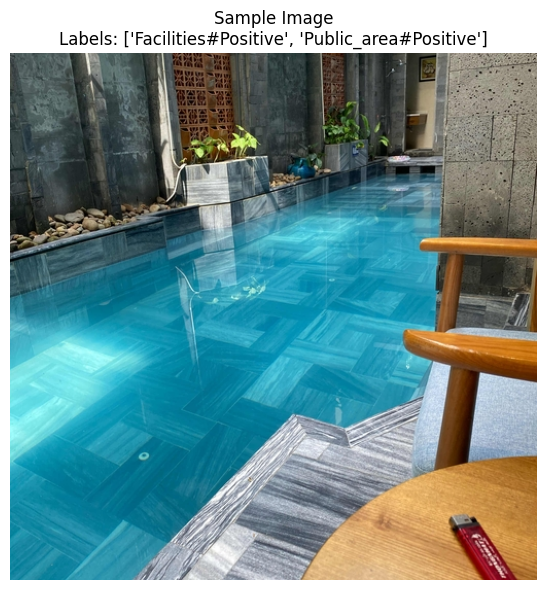


Image size: (512, 512)
Image mode: RGB

LABEL DISTRIBUTION:

Total labels: 8650
Unique labels: 18

Top 10 most common labels:
  Service#Positive                          1723 (19.9%)
  Public_area#Positive                      1509 (17.4%)
  Room#Positive                             1497 (17.3%)
  Location#Positive                          689 (8.0%)
  Facilities#Positive                        557 (6.4%)
  Public_area#Neutral                        519 (6.0%)
  Food#Positive                              444 (5.1%)
  Room#Neutral                               345 (4.0%)
  Room#Negative                              307 (3.5%)
  Facilities#Neutral                         208 (2.4%)


In [5]:
# ============================================
# DEMO DATASET STRUCTURE
# ============================================

import json
import os
from PIL import Image
import matplotlib.pyplot as plt

# Duong dan dataset
DATA_DIR = "datasets"
IMAGE_DIR = os.path.join(DATA_DIR, "image")

# Load 1 sample tu train.json
with open(os.path.join(DATA_DIR, "train.json"), 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"Total training samples: {len(train_data)}")
print("\n" + "=" * 80)
print("SAMPLE DATA STRUCTURE:")
print("=" * 80)

# Hien thi 1 sample
sample = train_data[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"\nComment: {sample.get('comment', 'N/A')}")
print(f"\nImage files: {sample.get('list_img', [])}")
print(f"\nLabels (text_img_label): {sample.get('text_img_label', [])}")

# Load va hien thi anh dau tien (neu co)
if sample.get('list_img') and len(sample['list_img']) > 0:
    img_path = os.path.join(IMAGE_DIR, sample['list_img'][0])
    if os.path.exists(img_path):
        print(f"\nImage path: {img_path}")
        
        # Hien thi anh
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample Image\nLabels: {sample.get('text_img_label', [])}")
        plt.tight_layout()
        plt.show()
        
        print(f"\nImage size: {img.size}")
        print(f"Image mode: {img.mode}")
    else:
        print(f"\n[WARNING] Image not found: {img_path}")

print("\n" + "=" * 80)
print("LABEL DISTRIBUTION:")
print("=" * 80)

# Dem phan bo labels
from collections import Counter
all_labels = []
for item in train_data:
    labels = item.get('text_img_label', [])
    all_labels.extend(labels)

label_counts = Counter(all_labels)
print(f"\nTotal labels: {len(all_labels)}")
print(f"Unique labels: {len(label_counts)}")
print(f"\nTop 10 most common labels:")
for label, count in label_counts.most_common(10):
    print(f"  {label:<40} {count:>5} ({count/len(all_labels)*100:.1f}%)")

---
## 2. Preprocessor và Swin Transformer V2 (Vision Encoder)

In [6]:
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

# ============================================
# PREPROCESSOR - Chuyen doi anh sang tensor
# ============================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size=256):
    """
    Preprocessor (Evaluation/Test): Image -> Tensor
    
    Input: PIL Image (any size)
    Output: Tensor [3, input_size, input_size] normalized
    """
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

def build_train_transform(input_size=256):
    """
    Preprocessor (Training): Image -> Tensor with data augmentation.
    
    Augmentations:
    - Resize to 110% -> RandomCrop back to input_size
    - RandomHorizontalFlip (p=0.5)
    - ColorJitter (brightness, contrast, saturation)
    
    Input: PIL Image (any size)
    Output: Tensor [3, input_size, input_size] normalized
    """
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((int(input_size * 1.1), int(input_size * 1.1)), interpolation=InterpolationMode.BICUBIC),
        T.RandomCrop(input_size),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

# ============================================
# SWIN TRANSFORMER V2 - Vision Encoder
# ============================================

class VisionEncoder(nn.Module):
    """
    Swin Transformer V2: Image -> Hierarchical features -> Img tokens
    
    Input: Tensor [B, 3, 256, 256]
    Output: Img tokens [B, 64, 1024]
    """
    
    def __init__(
        self, 
        model_name: str = "microsoft/swinv2-base-patch4-window8-256",
        device: str = "cuda",
        torch_dtype: torch.dtype = torch.float16
    ):
        super().__init__()
        self.device = device
        self.torch_dtype = torch_dtype
        
        print(f"Loading Swin Transformer V2: {model_name}")
        self.model = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch_dtype
        ).to(device)
        
        # Freeze weights
        for param in self.model.parameters():
            param.requires_grad = False
        self.model.eval()
        
        # Swin Transformer V2 Base: hidden_size = 1024
        self.hidden_size = self.model.config.hidden_size  # 1024
        
        # Auto-compute num_patches via a dummy forward pass
        # (avoids hardcoding 64 which only holds for input_size=256 + this specific model)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 256, 256, dtype=torch_dtype, device=device)
            dummy_out = self.model(pixel_values=dummy).last_hidden_state
            self.num_patches = dummy_out.shape[1]
        
        print(f"Loaded: hidden_size={self.hidden_size}, num_patches={self.num_patches} (auto-detected)")
    
    @torch.no_grad()
    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Extract visual features using Swin Transformer V2.
        
        Input: [B, 3, 256, 256]
        Output: [B, 64, 1024] - Img tokens
        """

        pixel_values = pixel_values.to(self.device, dtype=self.torch_dtype)

        outputs = self.model(pixel_values=pixel_values)
        return outputs.last_hidden_state  # [B, 64, 1024]

---
## 3. Projection Layer (MLP)

In [ ]:

class MLPProjector(nn.Module):
    """
    Projection: Img tokens -> Lang tokens
    
    Input: [B, 64, 1024] tu Swin Transformer V2
    Output: [B, 64, 4096] cho LLM
    
    Last layer zero-initialized (LLaVA trick):
    -> Ban dau output ~ 0 -> LLM "thay" image tokens nhu padding
    -> Projector dan hoc tao meaningful tokens trong qua trinh train
    -> Tranh NaN khi LLM nhan random embeddings tu untrained projector
    """
    
    def __init__(
        self,
        vision_dim: int = 1024,   # Swin Transformer V2 hidden dim
        llm_dim: int = 4096,      # LLM hidden dim (InternLM3-8B = 4096)
    ):
        super().__init__()
        
        self.projector = nn.Sequential(
            nn.LayerNorm(vision_dim),
            nn.Linear(vision_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
        )
        
        # Step 1: Xavier-init all Linear layers EXCEPT the last one
        for module in list(self.projector)[:-1]:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        # Step 2: Zero-init ONLY the last linear layer (LLaVA trick)
        # -> output starts at ~0, LLM won't produce NaN from untrained projector
        # Separated from Step 1 so reordering the loop above won't overwrite this
        last_linear = self.projector[-1]
        nn.init.zeros_(last_linear.weight)
        nn.init.zeros_(last_linear.bias)
    
    def forward(self, img_tokens: torch.Tensor) -> torch.Tensor:
        """
        Project Img tokens to Lang tokens.
        
        Input: [B, 64, 1024]
        Output: [B, 64, 4096]
        """
        # Cast input to match projector weight dtype (float16 -> float32)
        img_tokens = img_tokens.to(dtype=self.projector[0].weight.dtype)
        return self.projector(img_tokens)


In [8]:
# ============================================
# KHOI TAO VISION ENCODER VA PROJECTOR
# ============================================

# Tao Vision Encoder - Swin Transformer V2
# Dung COMPUTE_DTYPE (bf16/fp16) thong nhat voi LLM
vision_encoder = VisionEncoder(
    model_name="microsoft/swinv2-base-patch4-window8-256",
    device=device,
    torch_dtype=COMPUTE_DTYPE
)

# Tao Projection Layer - chuyen tu Swin features sang LLM space
# InternLM3-8B hidden_size = 4096
projector = MLPProjector(
    vision_dim=1024,   # Swin V2 Base hidden dim
    llm_dim=4096,      # InternLM3-8B hidden dim
).to(device)  # float32 - trainable layer needs stable gradients

print(f"  Vision hidden dim: {vision_encoder.hidden_size}")
print(f"  Vision num patches: {vision_encoder.num_patches}")
print(f"  Projector trainable params: {sum(p.numel() for p in projector.parameters()):,}")

Loading Swin Transformer V2: microsoft/swinv2-base-patch4-window8-256


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Swinv2Model LOAD REPORT from: microsoft/swinv2-base-patch4-window8-256
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: hidden_size=1024, num_patches=64 (auto-detected)
  Vision hidden dim: 1024
  Vision num patches: 64
  Projector trainable params: 20,981,760


In [9]:
# ============================================
# TEST 1: VisionEncoder + MLPProjector
# Categories: Runtime, Architecture, Memory, Code Quality
# ============================================
print("=" * 60)
print("TEST 1: VisionEncoder + MLPProjector")
print("=" * 60)
_t1_passed = 0
_t1_total = 0

# --- Runtime: forward with random input ---
_t1_total += 1
dummy_img = torch.randn(2, 3, 256, 256, dtype=COMPUTE_DTYPE, device=device)
with torch.no_grad():
    ve_out = vision_encoder(dummy_img)
assert ve_out.shape == (2, 64, 1024), f"VisionEncoder shape mismatch: {ve_out.shape}"
assert torch.isfinite(ve_out).all(), "VisionEncoder output has NaN/Inf"
print(f"  [PASS] VisionEncoder forward: shape={ve_out.shape}, dtype={ve_out.dtype}")
_t1_passed += 1

# --- Runtime: forward with all-zero input (no crash, no NaN) ---
_t1_total += 1
dummy_zero = torch.zeros(1, 3, 256, 256, dtype=COMPUTE_DTYPE, device=device)
with torch.no_grad():
    ve_zero_out = vision_encoder(dummy_zero)
assert ve_zero_out.shape == (1, 64, 1024), f"VisionEncoder zero-input shape: {ve_zero_out.shape}"
assert torch.isfinite(ve_zero_out).all(), "VisionEncoder zero-input has NaN/Inf"
print(f"  [PASS] VisionEncoder zero-input: no crash, no NaN/Inf")
_t1_passed += 1

# --- Runtime: single image [1,3,256,256] ---
_t1_total += 1
dummy_single = torch.randn(1, 3, 256, 256, dtype=COMPUTE_DTYPE, device=device)
with torch.no_grad():
    ve_single = vision_encoder(dummy_single)
assert ve_single.shape == (1, 64, 1024), f"Single image shape: {ve_single.shape}"
print(f"  [PASS] VisionEncoder single image: shape={ve_single.shape}")
_t1_passed += 1

# --- Architecture: hidden_size matches projector input dim ---
_t1_total += 1
proj_input_dim = projector.projector[1].in_features  # Linear layer after LayerNorm
assert vision_encoder.hidden_size == proj_input_dim, \
    f"Dim mismatch: vision={vision_encoder.hidden_size}, projector_in={proj_input_dim}"
print(f"  [PASS] Architecture wiring: vision_hidden={vision_encoder.hidden_size} == projector_in={proj_input_dim}")
_t1_passed += 1

# --- Architecture: projector output dim matches LLM hidden_size (4096) ---
_t1_total += 1
proj_output_dim = projector.projector[-1].out_features
assert proj_output_dim == 4096, f"Projector output dim: {proj_output_dim} != 4096"
print(f"  [PASS] Projector output dim: {proj_output_dim} == 4096 (LLM hidden_size)")
_t1_passed += 1

# --- Architecture: projector last layer is zero-initialized (LLaVA trick) ---
_t1_total += 1
last_linear = projector.projector[-1]
assert (last_linear.weight == 0).all(), "Projector last layer weight NOT zero-init"
assert (last_linear.bias == 0).all(), "Projector last layer bias NOT zero-init"
print(f"  [PASS] Projector last layer zero-initialized (LLaVA trick)")
_t1_passed += 1

# --- Architecture: projector output ~0 due to zero-init ---
_t1_total += 1
proj_out = projector(ve_out.float())
assert proj_out.shape == (2, 64, 4096), f"Projector output shape: {proj_out.shape}"
assert proj_out.abs().max().item() < 1e-6, \
    f"Projector output should be ~0 (zero-init), but max={proj_out.abs().max().item()}"
print(f"  [PASS] Projector output ~0 (zero-init): max={proj_out.abs().max().item():.2e}")
_t1_passed += 1

# --- Memory: vision_encoder all frozen ---
_t1_total += 1
ve_trainable = sum(1 for p in vision_encoder.parameters() if p.requires_grad)
assert ve_trainable == 0, f"VisionEncoder has {ve_trainable} trainable params (should be 0)"
print(f"  [PASS] VisionEncoder fully frozen: 0 trainable params")
_t1_passed += 1

# --- Dtype: vision_encoder uses COMPUTE_DTYPE ---
_t1_total += 1
assert vision_encoder.torch_dtype == COMPUTE_DTYPE, \
    f"VisionEncoder dtype: {vision_encoder.torch_dtype} != COMPUTE_DTYPE={COMPUTE_DTYPE}"
print(f"  [PASS] VisionEncoder dtype: {vision_encoder.torch_dtype} == COMPUTE_DTYPE")
_t1_passed += 1

# --- Dtype: projector weights are float32 (trainable) ---
_t1_total += 1
proj_dtype = next(projector.parameters()).dtype
assert proj_dtype == torch.float32, f"Projector dtype: {proj_dtype} != float32"
print(f"  [PASS] Projector dtype: float32 (stable gradients)")
_t1_passed += 1

# --- Code Quality: num_patches auto-detected matches expected ---
_t1_total += 1
assert vision_encoder.num_patches == 64, \
    f"num_patches={vision_encoder.num_patches} != 64 for 256x256 Swin V2 Base"
print(f"  [PASS] num_patches={vision_encoder.num_patches} (auto-detected, correct for 256x256)")
_t1_passed += 1

# Cleanup
del dummy_img, dummy_zero, dummy_single, ve_out, ve_zero_out, ve_single, proj_out
torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"TEST 1 RESULT: {_t1_passed}/{_t1_total} PASSED")
assert _t1_passed == _t1_total, f"TEST 1 FAILED: {_t1_total - _t1_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 1: VisionEncoder + MLPProjector
  [PASS] VisionEncoder forward: shape=torch.Size([2, 64, 1024]), dtype=torch.bfloat16
  [PASS] VisionEncoder zero-input: no crash, no NaN/Inf
  [PASS] VisionEncoder single image: shape=torch.Size([1, 64, 1024])
  [PASS] Architecture wiring: vision_hidden=1024 == projector_in=1024
  [PASS] Projector output dim: 4096 == 4096 (LLM hidden_size)
  [PASS] Projector last layer zero-initialized (LLaVA trick)
  [PASS] Projector output ~0 (zero-init): max=0.00e+00
  [PASS] VisionEncoder fully frozen: 0 trainable params
  [PASS] VisionEncoder dtype: torch.bfloat16 == COMPUTE_DTYPE
  [PASS] Projector dtype: float32 (stable gradients)
  [PASS] num_patches=64 (auto-detected, correct for 256x256)

TEST 1 RESULT: 11/11 PASSED
ALL TESTS PASSED


---
## 4. LLM - InternLM3-8B-Instruct

In [10]:
# ============================================
# LOAD LLM - InternLM3-8B-Instruct
# ============================================
# InternLM3 la pure LLM (khong co ViT nhu InternVL3)
# -> Khong can FIX patch cho InternViT
# -> Khong load ViT thua, tiet kiem ~6GB VRAM
# -> Truy cap truc tiep model (khong can .language_model)

import sys
import os
from pathlib import Path
from typing import Optional

# ============================================
# PATCH: InternLM3 remote code imports LossKwargs
# from transformers.utils, but it doesn't exist
# in transformers < 4.47. We inject a minimal stub
# so the import succeeds. If transformers is upgraded
# and LossKwargs already exists, this is a no-op.
# ============================================
import transformers
import transformers.utils as _tu
_transformers_version = tuple(int(x) for x in transformers.__version__.split('.')[:2])
if not hasattr(_tu, "LossKwargs"):
    from typing import TypedDict
    class LossKwargs(TypedDict, total=False):
        num_items_in_batch: Optional[int]
    _tu.LossKwargs = LossKwargs
    print(f"[PATCH] Injected LossKwargs into transformers.utils (transformers {transformers.__version__})")
else:
    print(f"[OK] LossKwargs already exists in transformers {transformers.__version__}, no patch needed")

MODEL_NAME = "internlm/internlm3-8b-instruct"

print(f"Loading {MODEL_NAME}...")
print("Lan dau se download ~16GB, vui long cho...")

# Dung COMPUTE_DTYPE da xac dinh tu dau (thong nhat voi vision encoder)
torch_dtype = COMPUTE_DTYPE

# ============================================
# WARNING: trust_remote_code=True allows execution of arbitrary code
# from the HuggingFace Hub. Only use with models you trust.
# InternLM3 requires this for its custom architecture code.
# ============================================

# Load tokenizer (Text -> word-pieces -> Embeddings -> Lang tokens)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True  # Required for InternLM3 custom code
)

# For batched classification with inputs_embeds, make padding explicit/stable
if tokenizer.pad_token_id is None:
    if tokenizer.eos_token_id is not None:
        tokenizer.pad_token = tokenizer.eos_token
    elif tokenizer.unk_token_id is not None:
        tokenizer.pad_token = tokenizer.unk_token
    else:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})

# NOTE: padding_side='right' is standard for causal LM training.
# For classification, we use _last_valid_indices() to find the last real token,
# so right-padding is safe. If switching to left-padding for generation tasks,
# update the pooling logic accordingly.
tokenizer.padding_side = 'right'
print(f"Tokenizer padding_side: {tokenizer.padding_side}")
print(f"Tokenizer pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

# ============================================
# Load model (Pure LLM - khong co ViT)
# Su dung AutoModelForCausalLM thay vi AutoModel
# ============================================
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,  # Required for InternLM3 custom code
    attn_implementation='eager',
).to(device).eval()

print(f"Model loaded!")
print(f"  Model type: {type(model).__name__}")
print(f"  Hidden size: {model.config.hidden_size}")
print(f"  Num layers: {model.config.num_hidden_layers}")
print(f"  Dtype: {torch_dtype}")

[PATCH] Injected LossKwargs into transformers.utils (transformers 5.3.0)
Loading internlm/internlm3-8b-instruct...
Lan dau se download ~16GB, vui long cho...


/opt/conda/lib/python3.11/site-packages/transformers/modeling_rope_utils.py:936: FutureWarning: `rope_config_validation` is deprecated and has been removed. Its functionality has been moved to RotaryEmbeddingConfigMixin.validate_rope method. PreTrainedConfig inherits this class, so please call self.validate_rope() instead. Also, make sure to use the new rope_parameters syntax. You can call self.standardize_rope_params() in the meantime.
  warnings.warn(
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


Tokenizer padding_side: right
Tokenizer pad_token: </s> (id=2)


Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

Model loaded!
  Model type: InternLM3ForCausalLM
  Hidden size: 4096
  Num layers: 48
  Dtype: torch.bfloat16


In [11]:
# ============================================
# TEST 2: LLM + Tokenizer
# Categories: Runtime, Architecture, Dtype, Code Quality
# ============================================
print("=" * 60)
print("TEST 2: LLM + Tokenizer")
print("=" * 60)
_t2_passed = 0
_t2_total = 0

# --- Runtime: tokenizer pad_token_id is set ---
_t2_total += 1
assert tokenizer.pad_token_id is not None, "tokenizer.pad_token_id is None!"
print(f"  [PASS] tokenizer.pad_token_id = {tokenizer.pad_token_id}")
_t2_passed += 1

# --- Runtime: tokenizer padding_side is 'right' ---
_t2_total += 1
assert tokenizer.padding_side == 'right', \
    f"tokenizer.padding_side = '{tokenizer.padding_side}' (expected 'right')"
print(f"  [PASS] tokenizer.padding_side = 'right'")
_t2_passed += 1

# --- Runtime: encode + decode roundtrip ---
_t2_total += 1
_test_text = "This hotel has great service."
_encoded = tokenizer(_test_text, return_tensors="pt")
_decoded = tokenizer.decode(_encoded.input_ids[0], skip_special_tokens=True)
assert _test_text.lower() in _decoded.lower() or _decoded.strip() != "", \
    f"Roundtrip failed: '{_test_text}' -> '{_decoded}'"
print(f"  [PASS] Tokenizer roundtrip: '{_test_text}' -> encode -> decode OK")
_t2_passed += 1

# --- Runtime: batch tokenization with padding ---
_t2_total += 1
_batch_texts = ["Short text.", "This is a much longer comment about the hotel room and service quality."]
_batch_enc = tokenizer(_batch_texts, padding=True, truncation=True, max_length=256, return_tensors="pt")
assert _batch_enc.input_ids.shape[0] == 2, f"Batch size mismatch: {_batch_enc.input_ids.shape[0]}"
assert _batch_enc.input_ids.shape == _batch_enc.attention_mask.shape, "input_ids/attention_mask shape mismatch"
# Right-padding: first row should have padding on the right
_seq_len_0 = _batch_enc.attention_mask[0].sum().item()
_seq_len_1 = _batch_enc.attention_mask[1].sum().item()
# The longer text should have more tokens
assert _seq_len_1 > _seq_len_0, f"Longer text has fewer tokens: {_seq_len_1} <= {_seq_len_0}"
print(f"  [PASS] Batch tokenization: shapes match, right-padding correct (lens: {_seq_len_0}, {_seq_len_1})")
_t2_passed += 1

# --- Architecture: hidden_size == 4096 ---
_t2_total += 1
assert model.config.hidden_size == 4096, \
    f"model.config.hidden_size = {model.config.hidden_size} (expected 4096)"
print(f"  [PASS] LLM hidden_size = {model.config.hidden_size}")
_t2_passed += 1

# --- Architecture: embedding output dim == hidden_size ---
_t2_total += 1
_embed_layer = model.get_input_embeddings()
_embed_dim = _embed_layer.embedding_dim
assert _embed_dim == model.config.hidden_size, \
    f"Embedding dim {_embed_dim} != hidden_size {model.config.hidden_size}"
print(f"  [PASS] Embedding dim = {_embed_dim} == hidden_size")
_t2_passed += 1

# --- Dtype: model params are COMPUTE_DTYPE ---
_t2_total += 1
_llm_param_dtype = next(model.parameters()).dtype
assert _llm_param_dtype == COMPUTE_DTYPE, \
    f"LLM param dtype: {_llm_param_dtype} != COMPUTE_DTYPE={COMPUTE_DTYPE}"
print(f"  [PASS] LLM param dtype = {_llm_param_dtype} == COMPUTE_DTYPE")
_t2_passed += 1

# --- Code Quality: MODEL_NAME matches ---
_t2_total += 1
assert MODEL_NAME == "internlm/internlm3-8b-instruct", \
    f"MODEL_NAME = '{MODEL_NAME}' (unexpected)"
print(f"  [PASS] MODEL_NAME = '{MODEL_NAME}'")
_t2_passed += 1

# --- Architecture: num_hidden_layers sanity ---
_t2_total += 1
assert model.config.num_hidden_layers > 0, "num_hidden_layers <= 0"
print(f"  [PASS] num_hidden_layers = {model.config.num_hidden_layers}")
_t2_passed += 1

# Cleanup
del _test_text, _encoded, _decoded, _batch_texts, _batch_enc

print(f"\n{'='*60}")
print(f"TEST 2 RESULT: {_t2_passed}/{_t2_total} PASSED")
assert _t2_passed == _t2_total, f"TEST 2 FAILED: {_t2_total - _t2_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 2: LLM + Tokenizer
  [PASS] tokenizer.pad_token_id = 2
  [PASS] tokenizer.padding_side = 'right'
  [PASS] Tokenizer roundtrip: 'This hotel has great service.' -> encode -> decode OK
  [PASS] Batch tokenization: shapes match, right-padding correct (lens: 4, 15)
  [PASS] LLM hidden_size = 4096
  [PASS] Embedding dim = 4096 == hidden_size
  [PASS] LLM param dtype = torch.bfloat16 == COMPUTE_DTYPE
  [PASS] MODEL_NAME = 'internlm/internlm3-8b-instruct'
  [PASS] num_hidden_layers = 48

TEST 2 RESULT: 9/9 PASSED
ALL TESTS PASSED


---
## 5. Dataset va DataLoader

In [12]:
import json
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ============================================
# LABEL DEFINITIONS - Unified 4-class per Aspect
# ============================================

# 6 Aspect Categories
ASPECT_LABELS = ["Facilities", "Public_area", "Location", "Food", "Room", "Service"]
ASPECT2ID = {label: idx for idx, label in enumerate(ASPECT_LABELS)}
ID2ASPECT = {idx: label for idx, label in enumerate(ASPECT_LABELS)}
NUM_ASPECTS = len(ASPECT_LABELS)

# 4 Classes per Aspect: 0=None(irrelevant), 1=Negative, 2=Neutral, 3=Positive
CLASS_LABELS = ["None", "Negative", "Neutral", "Positive"]
CLASS2ID = {label: idx for idx, label in enumerate(CLASS_LABELS)}
ID2CLASS = {idx: label for idx, label in enumerate(CLASS_LABELS)}
NUM_CLASSES = len(CLASS_LABELS)

# Mapping from old sentiment names to new class IDs
_SENTIMENT_TO_CLASS = {"Negative": 1, "Neutral": 2, "Positive": 3}

print(f"Aspect Categories ({NUM_ASPECTS}): {ASPECT_LABELS}")
print(f"Classes per Aspect ({NUM_CLASSES}): {CLASS_LABELS}")
print(f"Total output dim: {NUM_ASPECTS} x {NUM_CLASSES} = {NUM_ASPECTS * NUM_CLASSES}")

Aspect Categories (6): ['Facilities', 'Public_area', 'Location', 'Food', 'Room', 'Service']
Classes per Aspect (4): ['None', 'Negative', 'Neutral', 'Positive']
Total output dim: 6 x 4 = 24


In [13]:
# ============================================
# DATA LOADER - Doc train/dev/test.json
# ============================================

def load_dataset_json(json_path: str) -> list:
    """
    Doc file JSON dataset.
    
    Args:
        json_path: Duong dan toi file JSON
        
    Returns:
        List cac samples
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Loaded {len(data)} samples from {json_path}")
    return data


def load_all_splits(data_dir: str = "datasets"):
    """
    Load tat ca cac split: train, dev, test.
    
    Args:
        data_dir: Thu muc chua data
        
    Returns:
        Dict chua train, dev, test data
    """
    splits = {}
    for split in ["train", "dev", "test"]:
        json_path = os.path.join(data_dir, f"{split}.json")
        if os.path.exists(json_path):
            splits[split] = load_dataset_json(json_path)
        else:
            print(f"[WARNING] {json_path} not found!")
            splits[split] = []
    return splits


# Load data
DATA_DIR = "datasets"
IMAGE_DIR = os.path.join(DATA_DIR, "image")

dataset_splits = load_all_splits(DATA_DIR)

print(f"\nDataset Statistics:")
print(f"  Train: {len(dataset_splits['train'])} samples")
print(f"  Dev:   {len(dataset_splits['dev'])} samples")
print(f"  Test:  {len(dataset_splits['test'])} samples")

Loaded 2876 samples from datasets/train.json
Loaded 1000 samples from datasets/dev.json
Loaded 1000 samples from datasets/test.json

Dataset Statistics:
  Train: 2876 samples
  Dev:   1000 samples
  Test:  1000 samples


In [14]:
# ============================================
# PYTORCH DATASET CLASS - Unified Head (4-class per Aspect)
# Multi-image support, collate_fn uses closure
# ============================================

MAX_IMAGES = 5  # Cap number of images per sample

class SentimentDataset(Dataset):
    """
    PyTorch Dataset cho Aspect-Category Sentiment Analysis (Unified Head).
    
    Uses ALL images per sample (up to MAX_IMAGES).
    
    Moi sample gom:
    - comment: Text binh luan
    - image_paths: ALL valid image paths (up to MAX_IMAGES)
    - labels: [6] int tensor - class ID cho moi aspect
        0 = None (aspect khong xuat hien)
        1 = Negative
        2 = Neutral
        3 = Positive
    
    VD: ["Room#Positive", "Service#Negative"]
    -> labels: [0, 0, 0, 0, 3, 1]
               Facilities  Public  Location  Food  Room:Pos  Service:Neg
    """
    
    def __init__(
        self,
        data: list,
        image_dir: str,
        aspect2id: dict,
        transform=None,
    ):
        self.data = data
        self.image_dir = image_dir
        self.aspect2id = aspect2id
        self.num_aspects = len(aspect2id)
        self.transform = transform if transform else build_transform(256)
        
        self.samples = self._prepare_samples()
        print(f"Prepared {len(self.samples)} valid samples")
    
    def _parse_label(self, label: str):
        """
        Parse label goc thanh (aspect, sentiment).
        VD: 'Room#Positive' -> ('Room', 'Positive')
        Returns None neu label khong hop le.
        """
        if "#" not in label:
            return None
        parts = label.split("#")
        if len(parts) != 2:
            return None
        aspect, sentiment = parts[0], parts[1]
        if aspect in self.aspect2id and sentiment in _SENTIMENT_TO_CLASS:
            return (aspect, sentiment)
        return None
    
    def _prepare_samples(self) -> list:
        """Loc va chuan bi samples hop le. Giu TAT CA anh hop le (up to MAX_IMAGES)."""
        valid_samples = []
        
        for item in self.data:
            if not item.get("list_img") or len(item["list_img"]) == 0:
                continue
            
            raw_labels = item.get("text_img_label", [])
            if not raw_labels:
                continue
            
            # Parse tung label thanh (aspect, sentiment)
            parsed_labels = []
            for label in raw_labels:
                parsed = self._parse_label(label)
                if parsed is not None:
                    parsed_labels.append(parsed)
            
            if not parsed_labels:
                continue
            
            # Collect ALL valid image paths (up to MAX_IMAGES)
            valid_img_paths = []
            for img_name in item["list_img"][:MAX_IMAGES]:
                img_path = os.path.join(self.image_dir, img_name)
                if os.path.exists(img_path):
                    valid_img_paths.append(img_path)
            
            if not valid_img_paths:
                continue
            
            valid_samples.append({
                "comment": item.get("comment", ""),
                "image_paths": valid_img_paths,
                "parsed_labels": parsed_labels,
                "raw_labels": raw_labels,
            })
        
        return valid_samples
    
    def __len__(self):
        return len(self.samples)
    
    def _labels_to_tensor(self, parsed_labels: list) -> torch.Tensor:
        """
        Convert list of (aspect, sentiment) thanh unified label tensor [num_aspects].
        
        Moi aspect nhan 1 trong 4 class:
          0 = None (khong xuat hien)
          1 = Negative
          2 = Neutral
          3 = Positive
        
        Note: Neu cung aspect xuat hien nhieu lan voi sentiment khac nhau,
        chi giu sentiment cuoi cung (edge case, hiem gap trong ViMACSA).
        """
        labels = torch.zeros(self.num_aspects, dtype=torch.long)  # default 0 = None
        
        for aspect, sentiment in parsed_labels:
            a_id = self.aspect2id[aspect]
            labels[a_id] = _SENTIMENT_TO_CLASS[sentiment]
        
        return labels
    
    def __getitem__(self, idx: int) -> dict:
        sample = self.samples[idx]
        
        # Load ALL images and transform
        image_tensors = []
        for img_path in sample["image_paths"]:
            image = Image.open(img_path).convert("RGB")
            image_tensors.append(self.transform(image))
        
        pixel_values = torch.stack(image_tensors)  # [num_imgs, 3, 256, 256]
        
        # Convert labels to unified tensor
        labels = self._labels_to_tensor(sample["parsed_labels"])
        
        return {
            "pixel_values": pixel_values,    # [num_imgs, 3, 256, 256]
            "num_images": len(image_tensors),  # int
            "labels": labels,                  # [6] long, values 0-3
            "comment": sample["comment"],
            "image_paths": sample["image_paths"],
        }


def make_collate_fn(tokenizer_ref):
    """
    Tao collate function voi tokenizer reference (closure).
    
    Handles variable-length image lists via padding to max_imgs in batch.
    """
    def collate_fn(batch):
        # Handle variable number of images per sample
        image_counts = [item["num_images"] for item in batch]
        max_imgs = max(image_counts)
        
        padded_pixels = []
        for item in batch:
            pvs = item["pixel_values"]  # [num_imgs, 3, 256, 256]
            n = pvs.shape[0]
            if n < max_imgs:
                pad = torch.zeros(max_imgs - n, *pvs.shape[1:])
                padded_pixels.append(torch.cat([pvs, pad], dim=0))
            else:
                padded_pixels.append(pvs)
        
        pixel_values = torch.stack(padded_pixels)              # [B, max_imgs, 3, 256, 256]
        image_counts_tensor = torch.tensor(image_counts)       # [B]
        
        labels = torch.stack([item["labels"] for item in batch])  # [B, 6] long
        comments = [item["comment"] for item in batch]
        image_paths = [item["image_paths"] for item in batch]
        
        # Tokenizer: Text -> word-pieces (input_ids, attention_mask)
        text_inputs = tokenizer_ref(
            comments,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )
        
        return {
            "pixel_values": pixel_values,                       # [B, max_imgs, 3, 256, 256]
            "image_counts": image_counts_tensor,                # [B]
            "input_ids": text_inputs.input_ids,                 # [B, N]
            "attention_mask": text_inputs.attention_mask,       # [B, N]
            "labels": labels,                                    # [B, 6] long
            "comments": comments,
            "image_paths": image_paths,
        }
    
    return collate_fn

In [15]:
# ============================================
# TAO DATALOADERS (Unified Head, Multi-Image, Augmented)
# ============================================

# Training dataset WITH data augmentation
train_dataset = SentimentDataset(
    data=dataset_splits["train"],
    image_dir=IMAGE_DIR,
    aspect2id=ASPECT2ID,
    transform=build_train_transform(256),
)

# Dev/Test datasets WITHOUT augmentation
dev_dataset = SentimentDataset(
    data=dataset_splits["dev"],
    image_dir=IMAGE_DIR,
    aspect2id=ASPECT2ID,
    transform=build_transform(256),
)

test_dataset = SentimentDataset(
    data=dataset_splits["test"],
    image_dir=IMAGE_DIR,
    aspect2id=ASPECT2ID,
    transform=build_transform(256),
)

# Tao collate function (closure)
collate_fn = make_collate_fn(tokenizer)

# Tao dataloaders
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print(f"\nDataLoader Statistics:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Dev batches:   {len(dev_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# Test 1 batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  pixel_values shape: {sample_batch['pixel_values'].shape}")
print(f"  image_counts:       {sample_batch['image_counts'].tolist()}")
print(f"  labels shape:       {sample_batch['labels'].shape}")
print(f"  labels sample:      {sample_batch['labels'][0].tolist()}")

Prepared 2876 valid samples
Prepared 1000 valid samples
Prepared 1000 valid samples

DataLoader Statistics:
  Train batches: 360
  Dev batches:   125
  Test batches:  125

Sample batch:
  pixel_values shape: torch.Size([8, 3, 3, 256, 256])
  image_counts:       [3, 2, 2, 1, 3, 1, 2, 2]
  labels shape:       torch.Size([8, 6])
  labels sample:      [0, 0, 0, 3, 3, 3]


In [16]:
# ============================================
# TEST 3: Dataset + DataLoader + Collate
# Categories: Runtime, Logic, Padding, Code Quality
# ============================================
print("=" * 60)
print("TEST 3: Dataset + DataLoader + Collate")
print("=" * 60)
_t3_passed = 0
_t3_total = 0

# --- Code Quality: NUM_ASPECTS / NUM_CLASSES consistent ---
_t3_total += 1
assert NUM_ASPECTS == len(ASPECT_LABELS) == 6, \
    f"NUM_ASPECTS={NUM_ASPECTS}, len(ASPECT_LABELS)={len(ASPECT_LABELS)}"
assert NUM_CLASSES == len(CLASS_LABELS) == 4, \
    f"NUM_CLASSES={NUM_CLASSES}, len(CLASS_LABELS)={len(CLASS_LABELS)}"
assert len(ASPECT2ID) == NUM_ASPECTS
assert len(CLASS2ID) == NUM_CLASSES
print(f"  [PASS] Constants consistent: NUM_ASPECTS={NUM_ASPECTS}, NUM_CLASSES={NUM_CLASSES}")
_t3_passed += 1

# --- Runtime: single sample __getitem__ returns correct keys ---
_t3_total += 1
_sample0 = train_dataset[0]
_expected_keys = {"pixel_values", "num_images", "labels", "comment", "image_paths"}
assert set(_sample0.keys()) == _expected_keys, \
    f"Missing keys: {_expected_keys - set(_sample0.keys())}, extra: {set(_sample0.keys()) - _expected_keys}"
print(f"  [PASS] __getitem__ returns correct keys: {sorted(_sample0.keys())}")
_t3_passed += 1

# --- Runtime: pixel_values shape ---
_t3_total += 1
_pv = _sample0["pixel_values"]
assert _pv.dim() == 4, f"pixel_values should be 4D [N,3,256,256], got {_pv.dim()}D"
assert _pv.shape[1:] == (3, 256, 256), f"pixel_values channel/size: {_pv.shape[1:]}"
assert _pv.shape[0] == _sample0["num_images"], \
    f"num_images={_sample0['num_images']} != pixel_values.shape[0]={_pv.shape[0]}"
print(f"  [PASS] pixel_values shape: {_pv.shape} (num_images={_sample0['num_images']})")
_t3_passed += 1

# --- Logic: labels tensor values in {0,1,2,3} ---
_t3_total += 1
_labels = _sample0["labels"]
assert _labels.shape == (NUM_ASPECTS,), f"labels shape: {_labels.shape} != ({NUM_ASPECTS},)"
assert _labels.dtype == torch.long, f"labels dtype: {_labels.dtype} != long"
assert (_labels >= 0).all() and (_labels < NUM_CLASSES).all(), \
    f"labels out of range: {_labels.tolist()}"
print(f"  [PASS] Labels shape={_labels.shape}, dtype={_labels.dtype}, values={_labels.tolist()}")
_t3_passed += 1

# --- Logic: label parsing correctness ---
_t3_total += 1
# Test _parse_label manually
_test_ds = train_dataset
_parsed = _test_ds._parse_label("Room#Positive")
assert _parsed == ("Room", "Positive"), f"Parse 'Room#Positive' failed: {_parsed}"
_parsed2 = _test_ds._parse_label("InvalidLabel")
assert _parsed2 is None, f"Parse 'InvalidLabel' should be None: {_parsed2}"
_parsed3 = _test_ds._parse_label("Room#Unknown")
assert _parsed3 is None, f"Parse 'Room#Unknown' should be None: {_parsed3}"
print(f"  [PASS] _parse_label: valid/invalid cases handled correctly")
_t3_passed += 1

# --- Logic: _labels_to_tensor correctness ---
_t3_total += 1
_test_labels = _test_ds._labels_to_tensor([("Room", "Positive"), ("Service", "Negative")])
assert _test_labels[ASPECT2ID["Room"]] == 3, f"Room should be 3 (Positive), got {_test_labels[ASPECT2ID['Room']]}"
assert _test_labels[ASPECT2ID["Service"]] == 1, f"Service should be 1 (Negative), got {_test_labels[ASPECT2ID['Service']]}"
# All other aspects should be 0 (None)
for _asp in ["Facilities", "Public_area", "Location", "Food"]:
    assert _test_labels[ASPECT2ID[_asp]] == 0, f"{_asp} should be 0, got {_test_labels[ASPECT2ID[_asp]]}"
print(f"  [PASS] _labels_to_tensor: Room#Positive->3, Service#Negative->1, others->0")
_t3_passed += 1

# --- Runtime: collate_fn with single batch ---
_t3_total += 1
_batch = next(iter(train_loader))
_batch_keys = {"pixel_values", "image_counts", "input_ids", "attention_mask", "labels", "comments", "image_paths"}
assert set(_batch.keys()) == _batch_keys, \
    f"Batch keys mismatch: missing={_batch_keys - set(_batch.keys())}"
print(f"  [PASS] Collate produces correct keys: {sorted(_batch.keys())}")
_t3_passed += 1

# --- Runtime: collate shapes ---
_t3_total += 1
_B = _batch["pixel_values"].shape[0]
assert _batch["pixel_values"].dim() == 5, f"Batched pixel_values should be 5D, got {_batch['pixel_values'].dim()}D"
assert _batch["image_counts"].shape == (_B,), f"image_counts shape: {_batch['image_counts'].shape}"
assert _batch["labels"].shape == (_B, NUM_ASPECTS), f"labels shape: {_batch['labels'].shape}"
assert _batch["input_ids"].shape[0] == _B, f"input_ids batch size mismatch"
assert _batch["input_ids"].shape == _batch["attention_mask"].shape, "input_ids/attention_mask shape mismatch"
print(f"  [PASS] Batch shapes: B={_B}, pixel_values={_batch['pixel_values'].shape}, "
      f"labels={_batch['labels'].shape}, input_ids={_batch['input_ids'].shape}")
_t3_passed += 1

# --- Logic: image_counts match actual valid images ---
_t3_total += 1
_max_imgs = _batch["pixel_values"].shape[1]
for _i in range(_B):
    _ic = _batch["image_counts"][_i].item()
    assert 1 <= _ic <= MAX_IMAGES, f"Sample {_i}: image_count={_ic} out of [1, {MAX_IMAGES}]"
    assert _ic <= _max_imgs, f"Sample {_i}: image_count={_ic} > max_imgs={_max_imgs}"
print(f"  [PASS] image_counts valid: {_batch['image_counts'].tolist()} (max_imgs_in_batch={_max_imgs})")
_t3_passed += 1

# --- Padding: padded images should be zeros ---
_t3_total += 1
_pad_ok = True
for _i in range(_B):
    _ic = _batch["image_counts"][_i].item()
    if _ic < _max_imgs:
        _padded_region = _batch["pixel_values"][_i, _ic:]  # [pad_count, 3, 256, 256]
        if _padded_region.abs().sum().item() > 0:
            _pad_ok = False
            print(f"  [FAIL] Sample {_i}: padded images are NOT zero")
            break
if _pad_ok:
    print(f"  [PASS] Padded images are zero-filled")
    _t3_passed += 1
else:
    _t3_passed += 0  # already printed failure

# --- Logic: labels in valid range across batch ---
_t3_total += 1
assert (_batch["labels"] >= 0).all() and (_batch["labels"] < NUM_CLASSES).all(), \
    f"Batch labels out of range [0, {NUM_CLASSES})"
print(f"  [PASS] All batch labels in range [0, {NUM_CLASSES})")
_t3_passed += 1

# --- Code Quality: dataset sizes ---
_t3_total += 1
assert len(train_dataset) > 0, "train_dataset is empty"
assert len(dev_dataset) > 0, "dev_dataset is empty"
assert len(test_dataset) > 0, "test_dataset is empty"
print(f"  [PASS] Dataset sizes: train={len(train_dataset)}, dev={len(dev_dataset)}, test={len(test_dataset)}")
_t3_passed += 1

# Cleanup
del _sample0, _pv, _labels, _parsed, _parsed2, _parsed3, _test_labels, _batch

print(f"\n{'='*60}")
print(f"TEST 3 RESULT: {_t3_passed}/{_t3_total} PASSED")
assert _t3_passed == _t3_total, f"TEST 3 FAILED: {_t3_total - _t3_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 3: Dataset + DataLoader + Collate
  [PASS] Constants consistent: NUM_ASPECTS=6, NUM_CLASSES=4
  [PASS] __getitem__ returns correct keys: ['comment', 'image_paths', 'labels', 'num_images', 'pixel_values']
  [PASS] pixel_values shape: torch.Size([2, 3, 256, 256]) (num_images=2)
  [PASS] Labels shape=torch.Size([6]), dtype=torch.int64, values=[3, 3, 0, 0, 0, 0]
  [PASS] _parse_label: valid/invalid cases handled correctly
  [PASS] _labels_to_tensor: Room#Positive->3, Service#Negative->1, others->0
  [PASS] Collate produces correct keys: ['attention_mask', 'comments', 'image_counts', 'image_paths', 'input_ids', 'labels', 'pixel_values']
  [PASS] Batch shapes: B=8, pixel_values=torch.Size([8, 5, 3, 256, 256]), labels=torch.Size([8, 6]), input_ids=torch.Size([8, 247])
  [PASS] image_counts valid: [1, 3, 3, 3, 5, 1, 4, 1] (max_imgs_in_batch=5)
  [PASS] Padded images are zero-filled
  [PASS] All batch labels in range [0, 4)
  [PASS] Dataset sizes: train=2876, dev=1000, test=1000

TEST 3 RE

---
## 6. Training Loop (Unified Head: 4-class per Aspect)


In [17]:
# Suppress transformers deprecation warning that causes logging error
import warnings
warnings.filterwarnings("ignore", message=".*AttentionMaskConverter.*")
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# ============================================
# MULTIMODAL SENTIMENT MODEL - UNIFIED HEAD
# ============================================

class MultimodalSentimentModel(nn.Module):
    """
    Unified Head Aspect-Category Sentiment Model.

    Each of 6 aspects is classified into exactly 1 of 4 classes:
      0 = None (irrelevant)
      1 = Negative
      2 = Neutral
      3 = Positive

    Shared backbone: Swin V2 + Projection + LLM -> Last-token representation h_last [B, 4096]

    Concat order: [image_tokens | text_tokens]
      -> Text tokens are LAST, so the last text token attends to ALL image + text tokens
      -> Last-token pooling: h_last = H[:, L-1, :] (richest context in causal LM)

    Unified Head:
      h_last [B, 4096] -> Linear(4096, 24) -> reshape [B, 6, 4]
      CrossEntropyLoss per aspect, no masking needed.
    """

    def __init__(
        self,
        vision_encoder: VisionEncoder,
        projector: MLPProjector,
        llm_model,
        tokenizer,
        num_aspects: int = 6,
        num_classes: int = 4,
        lora_r: int = 16,
        lora_alpha: int = 16,
        lora_dropout: float = 0.0,
    ):
        super().__init__()

        self.vision_encoder = vision_encoder
        self.projector = projector
        self.tokenizer = tokenizer
        self.num_aspects = num_aspects
        self.num_classes = num_classes
        self.fusion_mode = "text_guided_image_attention"

        # Detect LLM dtype and hidden size
        self.llm_dtype = next(llm_model.parameters()).dtype
        self.llm_hidden_size = llm_model.config.hidden_size  # 4096
        print(f"  LLM dtype: {self.llm_dtype}")
        print(f"  LLM hidden_size: {self.llm_hidden_size}")
        print(f"  Fusion mode: {self.fusion_mode}")

        # ============================================
        # APPLY LoRA TO LLM
        # ============================================
        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["q_proj", "v_proj"],
            bias="none",
            task_type=TaskType.CAUSAL_LM,
        )
        self.llm = get_peft_model(llm_model, lora_config)
        self.llm.print_trainable_parameters()

        # Needed so gradients flow through inputs_embeds to the projector
        self.llm.enable_input_require_grads()

        # Text Embeddings layer tu LLM (frozen)
        self.text_embeddings = self.llm.get_input_embeddings()
        for param in self.text_embeddings.parameters():
            param.requires_grad = False

        # Freeze vision encoder
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

        # ============================================
        # UNIFIED HEAD (trainable) - Single Linear
        # ============================================
        total_output_dim = num_aspects * num_classes  # 6 * 4 = 24
        self.unified_head = nn.Linear(self.llm_hidden_size, total_output_dim)

        # Initialize
        nn.init.xavier_uniform_(self.unified_head.weight)
        nn.init.zeros_(self.unified_head.bias)
        # unified_head stays float32 for gradient stability

        print(f"  Unified Head: {self.llm_hidden_size} -> {total_output_dim} "
              f"(= {num_aspects} aspects x {num_classes} classes)")

        # Dtype summary for debugging
        print(f"\n  [DTYPE SUMMARY]")
        print(f"    Vision Encoder:  {self.vision_encoder.torch_dtype}")
        print(f"    MLPProjector:    {next(self.projector.parameters()).dtype}")
        print(f"    LLM (decoder):   {self.llm_dtype}")
        print(f"    Text Embeddings: {next(self.text_embeddings.parameters()).dtype}")
        print(f"    Unified Head:    {next(self.unified_head.parameters()).dtype}")
        ve_dt = self.vision_encoder.torch_dtype
        if ve_dt != self.llm_dtype:
            print(f"    [WARN] Vision ({ve_dt}) != LLM ({self.llm_dtype}). "
                  f"Ensure COMPUTE_DTYPE is set consistently.")

        # Keep raw backward() finite for smoke/integration tests and optimizer steps.
        self._grad_safety_handles = []
        self._register_grad_safety_hooks()
        self.last_image_weights = None  # debug cache

    def train(self, mode=True):
        super().train(mode)
        self.vision_encoder.eval()
        self.llm.train(mode)
        return self

    def _make_grad_safety_hook(self):
        def hook(grad: torch.Tensor) -> torch.Tensor:
            if grad is None:
                return grad
            if torch.isfinite(grad).all():
                return grad
            return torch.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0)
        return hook

    def _register_grad_safety_hooks(self):
        grad_hook = self._make_grad_safety_hook()
        for _, param in self.named_parameters():
            if param.requires_grad:
                self._grad_safety_handles.append(param.register_hook(grad_hook))

    def _check_nan(self, tensor: torch.Tensor, name: str) -> torch.Tensor:
        """Check for NaN/Inf and log a warning instead of silently replacing.
        Returns sanitized tensor. Use sparingly — only at module boundaries."""
        has_nan = torch.isnan(tensor).any().item()
        has_inf = torch.isinf(tensor).any().item()
        if has_nan or has_inf:
            finite_vals = tensor[torch.isfinite(tensor)]
            if finite_vals.numel() > 0:
                print(f"[NaN-DETECT] {name}: nan={has_nan}, inf={has_inf}, "
                      f"range=[{finite_vals.min().item():.4f}, {finite_vals.max().item():.4f}]")
            else:
                print(f"[NaN-DETECT] {name}: nan={has_nan}, inf={has_inf}, "
                      f"ALL values are NaN/Inf (no finite values) — likely dtype mismatch")
            tensor = torch.nan_to_num(tensor, nan=0.0, posinf=1e4, neginf=-1e4)
        return tensor

    def _masked_text_summary(self, text_lang_tokens: torch.Tensor, attention_mask: torch.Tensor = None) -> torch.Tensor:
        """Masked mean over text tokens -> [B, H]."""
        if attention_mask is None:
            return text_lang_tokens.float().mean(dim=1)

        mask = attention_mask.to(device=text_lang_tokens.device, dtype=torch.float32).unsqueeze(-1)  # [B, T, 1]
        denom = mask.sum(dim=1).clamp(min=1.0)
        return (text_lang_tokens.float() * mask).sum(dim=1) / denom

    def _get_combined_embeds(self, pixel_values, input_ids, attention_mask, image_counts=None):
        """Build combined embeddings with text-guided attention over images."""
        B = pixel_values.shape[0]

        # ====== TEXT PATH (needed early for image attention query) ======
        with torch.no_grad():
            text_lang_tokens = self.text_embeddings(input_ids.to(pixel_values.device))  # [B, T, H]

        # ====== IMAGE PATH ======
        if pixel_values.dim() == 5:
            # pixel_values: [B, M, 3, 256, 256]
            M = pixel_values.shape[1]
            P = self.vision_encoder.num_patches

            if image_counts is None:
                image_counts = torch.full((B,), M, device=pixel_values.device, dtype=torch.long)
            else:
                image_counts = image_counts.to(device=pixel_values.device, dtype=torch.long).clamp(min=0, max=M)

            valid_mask_2d = torch.arange(M, device=pixel_values.device).unsqueeze(0) < image_counts.unsqueeze(1)  # [B, M]
            valid_indices = valid_mask_2d.reshape(-1).nonzero(as_tuple=True)[0]

            pixel_flat_all = pixel_values.reshape(B * M, *pixel_values.shape[2:])
            pixel_flat_valid = pixel_flat_all[valid_indices] if valid_indices.numel() > 0 else pixel_flat_all[:0]

            with torch.no_grad():
                if pixel_flat_valid.numel() > 0:
                    img_tokens_valid = self.vision_encoder(pixel_flat_valid)  # [N_valid, P, 1024]
                else:
                    img_tokens_valid = torch.zeros(
                        0, P, self.vision_encoder.hidden_size,
                        dtype=self.vision_encoder.torch_dtype,
                        device=pixel_values.device,
                    )

            img_tokens_bmpv = torch.zeros(
                B * M, P, self.vision_encoder.hidden_size,
                dtype=img_tokens_valid.dtype,
                device=img_tokens_valid.device,
            )
            if valid_indices.numel() > 0:
                img_tokens_bmpv[valid_indices] = img_tokens_valid
            img_tokens_bmpv = img_tokens_bmpv.reshape(B, M, P, self.vision_encoder.hidden_size)  # [B, M, P, 1024]

            # Project each image independently to LLM space
            img_tokens_f32 = self._check_nan(img_tokens_bmpv.float(), "vision_output")
            img_lang_tokens_bmph = self.projector(
                img_tokens_f32.reshape(B * M, P, self.vision_encoder.hidden_size)
            ).reshape(B, M, P, self.llm_hidden_size)  # [B, M, P, H]
            img_lang_tokens_bmph = self._check_nan(img_lang_tokens_bmph, "projector_output")

            # Text-guided image scoring (stabilized): cosine-like similarity + safe softmax
            text_summary = self._check_nan(self._masked_text_summary(text_lang_tokens, attention_mask), "text_summary")  # [B, H]
            image_summary = self._check_nan(img_lang_tokens_bmph.float().mean(dim=2), "image_summary")  # [B, M, H]

            text_unit = torch.nn.functional.normalize(text_summary, p=2, dim=-1, eps=1e-6)
            image_unit = torch.nn.functional.normalize(image_summary, p=2, dim=-1, eps=1e-6)
            image_scores = (image_unit * text_unit.unsqueeze(1)).sum(dim=-1)  # [B, M], roughly in [-1, 1]

            image_scores = image_scores.masked_fill(~valid_mask_2d, -1e4)
            image_scores = torch.clamp(image_scores, min=-30.0, max=30.0)
            image_scores = image_scores - image_scores.max(dim=1, keepdim=True).values

            image_weights = torch.softmax(image_scores, dim=1)  # [B, M]
            image_weights = torch.nan_to_num(image_weights, nan=0.0, posinf=0.0, neginf=0.0)
            image_weights = image_weights * valid_mask_2d.to(dtype=image_weights.dtype)
            image_weights = image_weights / image_weights.sum(dim=1, keepdim=True).clamp(min=1e-6)
            image_weights = torch.nan_to_num(image_weights, nan=0.0, posinf=0.0, neginf=0.0)
            self.last_image_weights = image_weights.detach()

            # Weighted sum over image dimension -> keep patch resolution
            img_lang_tokens = (
                img_lang_tokens_bmph * image_weights.unsqueeze(-1).unsqueeze(-1)
            ).sum(dim=1)  # [B, P, H]
            img_lang_tokens = self._check_nan(img_lang_tokens, "weighted_img_tokens")

            has_any_valid_image = valid_mask_2d.any(dim=1, keepdim=True)
            img_attn = has_any_valid_image.expand(B, img_lang_tokens.size(1)).to(dtype=torch.long)
        else:
            # Single-image path
            with torch.no_grad():
                img_tokens = self.vision_encoder(pixel_values)
            img_tokens_f32 = self._check_nan(img_tokens.float(), "vision_output")
            img_lang_tokens = self.projector(img_tokens_f32)  # [B, P, H]
            img_lang_tokens = self._check_nan(img_lang_tokens, "projector_output")
            self.last_image_weights = None
            img_attn = torch.ones(B, img_lang_tokens.size(1), device=img_lang_tokens.device, dtype=torch.long)

        # Cast BOTH to llm_dtype for decoder input
        img_lang_tokens = img_lang_tokens.to(dtype=self.llm_dtype)
        text_lang_tokens = text_lang_tokens.to(device=img_lang_tokens.device, dtype=self.llm_dtype)

        # ====== [image | text] concat ======
        combined_embeds = torch.cat([img_lang_tokens, text_lang_tokens], dim=1)

        # ====== Attention mask ======
        device = img_lang_tokens.device
        img_attn = img_attn.to(device=device, dtype=torch.long)

        if attention_mask is not None:
            text_attn = attention_mask.to(device=device, dtype=torch.long)
        else:
            text_attn = torch.ones(B, text_lang_tokens.size(1), device=device, dtype=torch.long)

        full_attention_mask = torch.cat([img_attn, text_attn], dim=1)
        return combined_embeds, full_attention_mask

    def _last_valid_indices(self, full_attention_mask: torch.Tensor) -> torch.Tensor:
        """Return the index of the last non-pad token for each sample, robust to left/right padding."""
        mask_long = full_attention_mask.long()
        # Guard: if any row is all-zeros (all padded), fall back to last position
        row_has_valid = mask_long.sum(dim=1) > 0  # [B]
        rev = torch.flip(mask_long, dims=[1])
        last_from_end = torch.argmax(rev, dim=1)
        last_idx = full_attention_mask.size(1) - 1 - last_from_end
        # For all-zero rows, use index 0 (safest fallback)
        last_idx = torch.where(row_has_valid, last_idx, torch.zeros_like(last_idx))
        return last_idx.long()

    def _llm_last_hidden(self, combined_embeds: torch.Tensor, full_attention_mask: torch.Tensor) -> torch.Tensor:
        """Run the PEFT-wrapped LLM and return the last hidden state."""
        combined_embeds = combined_embeds.to(dtype=self.llm_dtype)

        outputs = self.llm(
            inputs_embeds=combined_embeds,
            attention_mask=full_attention_mask,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )
        hidden_states = outputs.hidden_states[-1]

        return self._check_nan(hidden_states, "llm_hidden_states")

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        image_counts: torch.Tensor = None,
    ) -> dict:
        combined_embeds, full_attention_mask = self._get_combined_embeds(
            pixel_values, input_ids, attention_mask, image_counts
        )

        hidden_states = self._llm_last_hidden(combined_embeds, full_attention_mask)

        # ====== Last-token pooling ======
        seq_lengths = self._last_valid_indices(full_attention_mask)
        batch_indices = torch.arange(hidden_states.size(0), device=hidden_states.device)
        h_last = hidden_states[batch_indices, seq_lengths]  # [B, 4096]

        # Cast to float32 for head
        h_last_f32 = self._check_nan(h_last.float(), "h_last")
        h_last_f32 = torch.clamp(h_last_f32, -1e3, 1e3)

        # ====== UNIFIED HEAD (float32 for stable gradients) ======
        logits = self.unified_head(h_last_f32)  # [B, 24] float32
        logits = logits.view(-1, self.num_aspects, self.num_classes)  # [B, 6, 4]

        return {"logits": logits}

    def get_trainable_params(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


# Tao model (voi LoRA cho LLM)
sentiment_model = MultimodalSentimentModel(
    vision_encoder=vision_encoder,
    projector=projector,
    llm_model=model,
    tokenizer=tokenizer,
    num_aspects=NUM_ASPECTS,
    num_classes=NUM_CLASSES,
    lora_r=16,
    lora_alpha=16,
    lora_dropout=0.0,
).to(device)

total_params, trainable_params = sentiment_model.get_trainable_params()

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

  LLM dtype: torch.bfloat16
  LLM hidden_size: 4096
  Fusion mode: text_guided_image_attention
trainable params: 9,633,792 || all params: 8,813,875,200 || trainable%: 0.1093
  Unified Head: 4096 -> 24 (= 6 aspects x 4 classes)

  [DTYPE SUMMARY]
    Vision Encoder:  torch.bfloat16
    MLPProjector:    torch.float32
    LLM (decoder):   torch.bfloat16
    Text Embeddings: torch.bfloat16
    Unified Head:    torch.float32

Total parameters: 8,921,849,104
Trainable parameters: 30,713,880
Frozen parameters: 8,891,135,224


In [18]:
# ============================================
# TEST 4: MultimodalSentimentModel
# Categories: Runtime, Architecture, Logic, Dtype, Memory, Code Quality
# ============================================
print("=" * 60)
print("TEST 4: MultimodalSentimentModel")
print("=" * 60)
_t4_passed = 0
_t4_total = 0

# --- Architecture: unified_head dimensions ---
_t4_total += 1
assert sentiment_model.unified_head.in_features == sentiment_model.llm_hidden_size == 4096, \
    f"Head in_features={sentiment_model.unified_head.in_features} != llm_hidden={sentiment_model.llm_hidden_size}"
assert sentiment_model.unified_head.out_features == NUM_ASPECTS * NUM_CLASSES == 24, \
    f"Head out_features={sentiment_model.unified_head.out_features} != {NUM_ASPECTS}*{NUM_CLASSES}"
print(f"  [PASS] unified_head: {sentiment_model.unified_head.in_features} -> {sentiment_model.unified_head.out_features}")
_t4_passed += 1

# --- Architecture: LoRA applied to q_proj, v_proj ---
_t4_total += 1
_lora_names = [n for n, _ in sentiment_model.llm.named_parameters() if 'lora_' in n and _.requires_grad]
assert len(_lora_names) > 0, "No LoRA params found"
_lora_targets = set()
for _n in _lora_names:
    for _t in ['q_proj', 'v_proj']:
        if _t in _n:
            _lora_targets.add(_t)
assert _lora_targets == {'q_proj', 'v_proj'}, f"LoRA targets: {_lora_targets} (expected q_proj, v_proj)"
print(f"  [PASS] LoRA applied to: {sorted(_lora_targets)} ({len(_lora_names)} params)")
_t4_passed += 1

# --- Architecture: text_embeddings frozen ---
_t4_total += 1
_te_trainable = sum(1 for p in sentiment_model.text_embeddings.parameters() if p.requires_grad)
assert _te_trainable == 0, f"text_embeddings has {_te_trainable} trainable params"
print(f"  [PASS] text_embeddings fully frozen")
_t4_passed += 1

# --- Architecture: vision_encoder frozen inside model ---
_t4_total += 1
_ve_trainable = sum(1 for p in sentiment_model.vision_encoder.parameters() if p.requires_grad)
assert _ve_trainable == 0, f"vision_encoder has {_ve_trainable} trainable params inside model"
print(f"  [PASS] vision_encoder frozen inside model")
_t4_passed += 1

# --- Code Quality: trainable params = projector + head + LoRA only ---
_t4_total += 1
_trainable_groups = {"projector": 0, "unified_head": 0, "lora": 0, "other": 0}
for _name, _p in sentiment_model.named_parameters():
    if not _p.requires_grad:
        continue
    if "projector" in _name:
        _trainable_groups["projector"] += _p.numel()
    elif "unified_head" in _name:
        _trainable_groups["unified_head"] += _p.numel()
    elif "lora_" in _name:
        _trainable_groups["lora"] += _p.numel()
    else:
        _trainable_groups["other"] += _p.numel()
assert _trainable_groups["other"] == 0, \
    f"Unexpected trainable params outside projector/head/lora: {_trainable_groups['other']}"
print(f"  [PASS] Trainable param groups: projector={_trainable_groups['projector']:,}, "
      f"head={_trainable_groups['unified_head']:,}, lora={_trainable_groups['lora']:,}")
_t4_passed += 1

# --- Logic: _last_valid_indices with known mask ---
_t4_total += 1
_test_mask = torch.tensor([
    [1, 1, 1, 0, 0],  # last valid = 2
    [1, 1, 1, 1, 1],  # last valid = 4
    [1, 0, 0, 0, 0],  # last valid = 0
], device=device)
_last_idx = sentiment_model._last_valid_indices(_test_mask)
assert _last_idx.tolist() == [2, 4, 0], f"_last_valid_indices: {_last_idx.tolist()} != [2, 4, 0]"
print(f"  [PASS] _last_valid_indices: {_last_idx.tolist()} == [2, 4, 0]")
_t4_passed += 1

# --- Logic: _last_valid_indices all-zeros row ---
_t4_total += 1
_zero_mask = torch.tensor([[0, 0, 0]], device=device)
_zero_idx = sentiment_model._last_valid_indices(_zero_mask)
assert _zero_idx.item() == 0, f"All-zero mask should give index 0, got {_zero_idx.item()}"
print(f"  [PASS] _last_valid_indices all-zeros: falls back to index 0")
_t4_passed += 1

# --- Dtype: unified_head is float32 ---
_t4_total += 1
_head_dtype = next(sentiment_model.unified_head.parameters()).dtype
assert _head_dtype == torch.float32, f"unified_head dtype: {_head_dtype} != float32"
print(f"  [PASS] unified_head dtype: float32")
_t4_passed += 1

# --- Dtype: llm_dtype matches COMPUTE_DTYPE ---
_t4_total += 1
assert sentiment_model.llm_dtype == COMPUTE_DTYPE, \
    f"llm_dtype={sentiment_model.llm_dtype} != COMPUTE_DTYPE={COMPUTE_DTYPE}"
print(f"  [PASS] llm_dtype = {sentiment_model.llm_dtype} == COMPUTE_DTYPE")
_t4_passed += 1

# --- Runtime: forward with real batch → output shape, dtype, finite ---
_t4_total += 1
sentiment_model.eval()
_test_batch = next(iter(train_loader))
with torch.no_grad():
    _pv = _test_batch['pixel_values'].to(device, dtype=COMPUTE_DTYPE)
    _ic = _test_batch['image_counts'].to(device)
    _ids = _test_batch['input_ids'].to(device)
    _am = _test_batch['attention_mask'].to(device)
    _out = sentiment_model(_pv, _ids, _am, _ic)

_logits = _out['logits']
_B = _pv.shape[0]
assert _logits.shape == (_B, NUM_ASPECTS, NUM_CLASSES), \
    f"Output shape: {_logits.shape} != ({_B}, {NUM_ASPECTS}, {NUM_CLASSES})"
assert _logits.dtype == torch.float32, f"Logits dtype: {_logits.dtype} != float32"
assert torch.isfinite(_logits).all(), \
    f"Logits have NaN/Inf! range=[{_logits.min().item():.4f}, {_logits.max().item():.4f}]"
print(f"  [PASS] Forward: shape={_logits.shape}, dtype={_logits.dtype}, "
      f"range=[{_logits.min().item():.4f}, {_logits.max().item():.4f}]")
_t4_passed += 1

# --- Memory: flag output_hidden_states=True cost ---
_t4_total += 1
print(f"  [INFO] output_hidden_states=True is used in _llm_last_hidden (needed for last layer access)")
print(f"         This stores all {model.config.num_hidden_layers + 1} layer outputs in memory.")
print(f"         Known VRAM cost — no alternative without changing InternLM3 code.")
_t4_passed += 1  # info-only, always passes

# --- Architecture: num_aspects, num_classes stored correctly ---
_t4_total += 1
assert sentiment_model.num_aspects == NUM_ASPECTS, \
    f"model.num_aspects={sentiment_model.num_aspects} != {NUM_ASPECTS}"
assert sentiment_model.num_classes == NUM_CLASSES, \
    f"model.num_classes={sentiment_model.num_classes} != {NUM_CLASSES}"
print(f"  [PASS] Model stores num_aspects={sentiment_model.num_aspects}, num_classes={sentiment_model.num_classes}")
_t4_passed += 1

# Cleanup
del _lora_names, _lora_targets, _test_mask, _last_idx, _zero_mask, _zero_idx
del _test_batch, _pv, _ic, _ids, _am, _out, _logits
torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"TEST 4 RESULT: {_t4_passed}/{_t4_total} PASSED")
assert _t4_passed == _t4_total, f"TEST 4 FAILED: {_t4_total - _t4_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 4: MultimodalSentimentModel
  [PASS] unified_head: 4096 -> 24
  [PASS] LoRA applied to: ['q_proj', 'v_proj'] (192 params)
  [PASS] text_embeddings fully frozen
  [PASS] vision_encoder frozen inside model
  [PASS] Trainable param groups: projector=20,981,760, head=98,328, lora=9,633,792
  [PASS] _last_valid_indices: [2, 4, 0] == [2, 4, 0]
  [PASS] _last_valid_indices all-zeros: falls back to index 0
  [PASS] unified_head dtype: float32
  [PASS] llm_dtype = torch.bfloat16 == COMPUTE_DTYPE
  [PASS] Forward: shape=torch.Size([8, 6, 4]), dtype=torch.float32, range=[-1.9285, 2.3547]
  [INFO] output_hidden_states=True is used in _llm_last_hidden (needed for last layer access)
         This stores all 49 layer outputs in memory.
         Known VRAM cost — no alternative without changing InternLM3 code.
  [PASS] Model stores num_aspects=6, num_classes=4

TEST 4 RESULT: 12/12 PASSED
ALL TESTS PASSED


In [19]:
# TRAINING CONFIGURATION - Unified Head
# ============================================

from torch.optim import AdamW
import math

# Hyperparameters
LEARNING_RATE = 2e-5      # For projector + head
LORA_LR = 1e-6            # Much smaller LR for LoRA
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 10
WARMUP_PROPORTION = 0.1
GRADIENT_ACCUMULATION_STEPS = 2

# ============================================
# NO GRADIENT CHECKPOINTING
# Disabled to avoid NaN gradients with InternLM3 custom attention + inputs_embeds.
# Uses more VRAM but ensures clean backward pass.
# ============================================
sentiment_model.llm.gradient_checkpointing_disable()
print("[OK] Gradient checkpointing DISABLED")

# ============================================
# CLASS WEIGHTS - penalize misclassifying sentiment classes vs None
# Class 0 (None) is dominant, so we down-weight it
# ============================================
class_weights = torch.tensor([0.2, 1.0, 1.0, 1.0], device=device, dtype=torch.float32)
print(f"  Class weights: {class_weights.tolist()}")

# ============================================
# SEPARATE PARAM GROUPS
# ============================================
head_named_params = []
lora_named_params = []

for name, param in sentiment_model.named_parameters():
    if not param.requires_grad:
        continue
    if 'lora_' in name:
        lora_named_params.append((name, param))
    else:
        head_named_params.append((name, param))

head_params = [param for _, param in head_named_params]
lora_params = [param for _, param in lora_named_params]

captured_trainable = sum(p.numel() for p in head_params) + sum(p.numel() for p in lora_params)
all_trainable = sum(p.numel() for p in sentiment_model.parameters() if p.requires_grad)

print(f"  Head params (LR={LEARNING_RATE}): {sum(p.numel() for p in head_params):,}")
print(f"  LoRA params (LR={LORA_LR}): {sum(p.numel() for p in lora_params):,}")
print(f"  Captured trainable params: {captured_trainable:,}/{all_trainable:,}")

if captured_trainable != all_trainable:
    raise RuntimeError("Some trainable parameters were not assigned to optimizer groups")

optimizer = AdamW([
    {"params": head_params, "lr": LEARNING_RATE},
    {"params": lora_params, "lr": LORA_LR},
], weight_decay=WEIGHT_DECAY)

# Scheduler (count real optimizer steps, not raw batches)
steps_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_PROPORTION)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

class LazyLambdaScheduler:
    def __init__(self, optimizer, lr_lambda):
        self.optimizer = optimizer
        self.lr_lambda = lr_lambda
        self.base_lrs = []
        for group in optimizer.param_groups:
            base_lr = group['lr']
            group.setdefault('initial_lr', base_lr)
            self.base_lrs.append(base_lr)
        self._last_lr = list(self.base_lrs)
        self.last_epoch = -1
        self.started = False

    def _apply(self, step_idx):
        scale = float(self.lr_lambda(step_idx))
        self._last_lr = []
        for base_lr, group in zip(self.base_lrs, self.optimizer.param_groups):
            lr = base_lr * scale
            group['lr'] = lr
            self._last_lr.append(lr)
        self.last_epoch = step_idx

    def start(self):
        if self.started:
            return
        self.started = True
        self._apply(0)

    def step(self):
        if not self.started:
            self.start()
            return
        self._apply(self.last_epoch + 1)

    def get_last_lr(self):
        return list(self._last_lr)

scheduler = LazyLambdaScheduler(optimizer, lr_lambda)

# Loss function - single CrossEntropyLoss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"\nTraining Configuration:")
print(f"  Head LR: {LEARNING_RATE}, LoRA LR: {LORA_LR}")
print(f"  Epochs: {NUM_EPOCHS}, Steps/Epoch: {steps_per_epoch}, Total Steps: {total_steps}, Warmup: {warmup_steps}")
print(f"  Gradient Accumulation: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Gradient Checkpointing: DISABLED")
print(f"  Loss: CrossEntropyLoss(weight={class_weights.tolist()})")
print(f"  Early Stopping: enabled (patience will be set in training loop)")

[OK] Gradient checkpointing DISABLED
  Class weights: [0.20000000298023224, 1.0, 1.0, 1.0]
  Head params (LR=2e-05): 21,080,088
  LoRA params (LR=1e-06): 9,633,792
  Captured trainable params: 30,713,880/30,713,880

Training Configuration:
  Head LR: 2e-05, LoRA LR: 1e-06
  Epochs: 10, Steps/Epoch: 180, Total Steps: 1800, Warmup: 180
  Gradient Accumulation: 2
  Gradient Checkpointing: DISABLED
  Loss: CrossEntropyLoss(weight=[0.20000000298023224, 1.0, 1.0, 1.0])
  Early Stopping: enabled (patience will be set in training loop)


In [20]:
# ============================================
# TEST 5: Training Config + Optimizer + Scheduler
# Categories: Logic, Code Quality
# ============================================
print("=" * 60)
print("TEST 5: Training Config + Optimizer + Scheduler")
print("=" * 60)
_t5_passed = 0
_t5_total = 0

# --- Logic: gradient checkpointing is DISABLED ---
_t5_total += 1
# Check that gradient_checkpointing is not enabled on the underlying model
_gc_enabled = getattr(sentiment_model.llm, 'is_gradient_checkpointing', False)
if not _gc_enabled:
    # Also check the base model config
    _base_model = sentiment_model.llm.get_base_model()
    _gc_enabled = getattr(_base_model.config, 'gradient_checkpointing', False) if hasattr(_base_model, 'config') else False
assert not _gc_enabled, "Gradient checkpointing is ENABLED (should be DISABLED)"
print(f"  [PASS] Gradient checkpointing: DISABLED")
_t5_passed += 1

# --- Logic: all trainable params captured in optimizer ---
_t5_total += 1
_opt_param_count = sum(p.numel() for group in optimizer.param_groups for p in group['params'])
_model_trainable = sum(p.numel() for p in sentiment_model.parameters() if p.requires_grad)
assert _opt_param_count == _model_trainable, \
    f"Optimizer has {_opt_param_count:,} params but model has {_model_trainable:,} trainable"
print(f"  [PASS] Optimizer captures all trainable params: {_opt_param_count:,} == {_model_trainable:,}")
_t5_passed += 1

# --- Logic: 2 param groups (head + LoRA) ---
_t5_total += 1
assert len(optimizer.param_groups) == 2, f"Expected 2 param groups, got {len(optimizer.param_groups)}"
_lr_head = optimizer.param_groups[0]['lr']
_lr_lora = optimizer.param_groups[1]['lr']
assert _lr_head == LEARNING_RATE, f"Head LR={_lr_head} != {LEARNING_RATE}"
assert _lr_lora == LORA_LR, f"LoRA LR={_lr_lora} != {LORA_LR}"
print(f"  [PASS] 2 param groups: head LR={_lr_head}, LoRA LR={_lr_lora}")
_t5_passed += 1

# --- Logic: class_weights ---
_t5_total += 1
assert class_weights.shape == (NUM_CLASSES,), \
    f"class_weights shape: {class_weights.shape} != ({NUM_CLASSES},)"
assert class_weights[0].item() < 1.0, \
    f"class_weights[0] (None class) = {class_weights[0].item()} should be < 1.0 (down-weighted)"
assert all(class_weights[i].item() == 1.0 for i in range(1, NUM_CLASSES)), \
    f"Sentiment class weights should be 1.0: {class_weights[1:].tolist()}"
print(f"  [PASS] class_weights: {class_weights.tolist()} (None down-weighted)")
_t5_passed += 1

# --- Logic: scheduler warmup ---
_t5_total += 1
assert warmup_steps > 0, f"warmup_steps={warmup_steps} <= 0"
_lr_at_0 = lr_lambda(0)
_lr_at_warmup = lr_lambda(warmup_steps)
assert abs(_lr_at_0) < 1e-6, f"lr_lambda(0)={_lr_at_0} (should be ~0)"
assert abs(_lr_at_warmup - 1.0) < 0.05, f"lr_lambda(warmup)={_lr_at_warmup} (should be ~1.0)"
print(f"  [PASS] Scheduler: warmup_steps={warmup_steps}, lr_lambda(0)={_lr_at_0:.4f}, lr_lambda(warmup)={_lr_at_warmup:.4f}")
_t5_passed += 1

# --- Logic: scheduler cosine decay ---
_t5_total += 1
_lr_at_end = lr_lambda(total_steps)
assert _lr_at_end < 0.1, f"lr_lambda(total_steps)={_lr_at_end} (should be near 0)"
_lr_at_mid = lr_lambda((warmup_steps + total_steps) // 2)
assert _lr_at_mid < _lr_at_warmup, f"Mid-training LR should be less than peak"
print(f"  [PASS] Cosine schedule: lr_mid={_lr_at_mid:.4f}, lr_end={_lr_at_end:.4f}")
_t5_passed += 1

# --- Code Quality: GRADIENT_ACCUMULATION_STEPS consistent ---
_t5_total += 1
assert GRADIENT_ACCUMULATION_STEPS >= 1, f"GRADIENT_ACCUMULATION_STEPS={GRADIENT_ACCUMULATION_STEPS}"
_expected_steps_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
assert steps_per_epoch == _expected_steps_per_epoch, \
    f"steps_per_epoch={steps_per_epoch} != ceil({len(train_loader)}/{GRADIENT_ACCUMULATION_STEPS})"
print(f"  [PASS] GRADIENT_ACCUMULATION_STEPS={GRADIENT_ACCUMULATION_STEPS}, steps_per_epoch={steps_per_epoch}")
_t5_passed += 1

# --- Code Quality: criterion uses class_weights ---
_t5_total += 1
assert isinstance(criterion, nn.CrossEntropyLoss), f"criterion type: {type(criterion)}"
assert criterion.weight is not None, "criterion has no class weights"
assert torch.equal(criterion.weight, class_weights), "criterion weights don't match class_weights"
print(f"  [PASS] criterion: CrossEntropyLoss with matching class_weights")
_t5_passed += 1

print(f"\n{'='*60}")
print(f"TEST 5 RESULT: {_t5_passed}/{_t5_total} PASSED")
assert _t5_passed == _t5_total, f"TEST 5 FAILED: {_t5_total - _t5_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 5: Training Config + Optimizer + Scheduler
  [PASS] Gradient checkpointing: DISABLED
  [PASS] Optimizer captures all trainable params: 30,713,880 == 30,713,880
  [PASS] 2 param groups: head LR=2e-05, LoRA LR=1e-06
  [PASS] class_weights: [0.20000000298023224, 1.0, 1.0, 1.0] (None down-weighted)
  [PASS] Scheduler: warmup_steps=180, lr_lambda(0)=0.0000, lr_lambda(warmup)=1.0000
  [PASS] Cosine schedule: lr_mid=0.5000, lr_end=0.0000
  [PASS] GRADIENT_ACCUMULATION_STEPS=2, steps_per_epoch=180
  [PASS] criterion: CrossEntropyLoss with matching class_weights

TEST 5 RESULT: 8/8 PASSED
ALL TESTS PASSED


In [21]:
# ============================================
# PRE-TRAIN FORWARD SANITY CHECK
# Run this ONCE before the training loop. If this cell prints finite logits,
# the step-0 NaN issue is fixed at the forward path.
# ============================================

sentiment_model.eval()
batch0 = next(iter(train_loader))
with torch.no_grad():
    # Dung COMPUTE_DTYPE thong nhat (khong dung vision_encoder.torch_dtype rieng)
    pixel_values = batch0['pixel_values'].to(device, dtype=COMPUTE_DTYPE)
    image_counts = batch0['image_counts'].to(device)
    input_ids = batch0['input_ids'].to(device)
    attention_mask = batch0['attention_mask'].to(device)
    
    print(f'[DTYPE CHECK] pixel_values={pixel_values.dtype}, '
          f'vision_encoder={vision_encoder.torch_dtype}, '
          f'llm={sentiment_model.llm_dtype}, '
          f'projector={next(sentiment_model.projector.parameters()).dtype}')
    
    out0 = sentiment_model(pixel_values, input_ids, attention_mask, image_counts)

logits0 = out0['logits']  # [B, 6, 4]
print(f'tokenizer.padding_side={tokenizer.padding_side}, pad_token_id={tokenizer.pad_token_id}')

print(f'image_counts={image_counts.tolist()}')
print(f'text valid lengths={attention_mask.sum(dim=1).tolist()}')
print(f'logits shape={logits0.shape}')
print(f'logits finite={torch.isfinite(logits0).all().item()} range=[{logits0.min().item():.4f}, {logits0.max().item():.4f}]')
print(f'predictions (argmax): {logits0.argmax(dim=-1).tolist()}')

sentiment_model.train()

[DTYPE CHECK] pixel_values=torch.bfloat16, vision_encoder=torch.bfloat16, llm=torch.bfloat16, projector=torch.float32
tokenizer.padding_side=right, pad_token_id=2
image_counts=[4, 2, 2, 1, 3, 2, 1, 1]
text valid lengths=[75, 59, 58, 23, 20, 52, 54, 39]
logits shape=torch.Size([8, 6, 4])
logits finite=True range=[-2.0052, 2.8070]
predictions (argmax): [[0, 2, 3, 0, 3, 0], [0, 2, 3, 0, 3, 0], [0, 0, 3, 0, 3, 1], [0, 2, 0, 0, 2, 0], [0, 2, 3, 0, 1, 3], [0, 2, 3, 0, 3, 3], [0, 2, 3, 1, 3, 3], [0, 3, 3, 1, 3, 0]]


MultimodalSentimentModel(
  (vision_encoder): VisionEncoder(
    (model): Swinv2Model(
      (embeddings): Swinv2Embeddings(
        (patch_embeddings): Swinv2PatchEmbeddings(
          (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        )
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): Swinv2Encoder(
        (layers): ModuleList(
          (0): Swinv2Stage(
            (blocks): ModuleList(
              (0): Swinv2Layer(
                (attention): Swinv2Attention(
                  (self): Swinv2SelfAttention(
                    (continuous_position_bias_mlp): Sequential(
                      (0): Linear(in_features=2, out_features=512, bias=True)
                      (1): ReLU(inplace=True)
                      (2): Linear(in_features=512, out_features=4, bias=False)
                    )
                    (query): Linear(in_features=128, out_features=128, bias

In [22]:
# ============================================
# TRAINING LOOP - Unified Head
# ============================================

def compute_loss(logits, labels, criterion):
    """
    Tinh CrossEntropyLoss cho unified head.
    
    Args:
        logits: [B, 6, 4] raw logits
        labels: [B, 6] long, values 0-3
        criterion: CrossEntropyLoss (with class weights)
    
    Returns:
        loss: scalar
    """
    B, A, C = logits.shape

    # Guard non-finite logits before CE to prevent silent NaN propagation
    if not torch.isfinite(logits).all():
        return torch.tensor(float('nan'), device=logits.device, dtype=torch.float32)

    # CE is numerically safer in float32
    logits_2d = logits.reshape(B * A, C).float()
    labels_1d = labels.reshape(B * A).long()

    # Reshape for CrossEntropyLoss: (B*6, 4) vs (B*6,)
    return criterion(logits_2d, labels_1d)


def _sanitize_grads(model):
    """Check for NaN/Inf gradients, log warning, and zero them out.
    Returns count of sanitized params. Repeated NaN grads may indicate
    a deeper issue (e.g., LR too high, loss explosion)."""
    count = 0
    for name, p in model.named_parameters():
        if p.grad is not None:
            bad = torch.isnan(p.grad) | torch.isinf(p.grad)
            if bad.any():
                pct = bad.float().mean().item() * 100
                print(f"[WARN-GRAD] {name}: {pct:.1f}% NaN/Inf grads -> zeroed")
                p.grad[bad] = 0.0
                count += 1
    return count


def _optimizer_step(model, optimizer, scheduler):
    """Sanitize, clip, step, zero_grad. Returns number of sanitized params."""
    n_fixed = _sanitize_grads(model)
    if head_params:
        torch.nn.utils.clip_grad_norm_(head_params, max_norm=1.0)
    if lora_params:
        torch.nn.utils.clip_grad_norm_(lora_params, max_norm=0.3)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad(set_to_none=True)
    return n_fixed


def train_epoch(model, dataloader, optimizer, scheduler,
                criterion, device, gradient_accumulation_steps=1):
    """Train 1 epoch with autocast wrapping forward+loss for gradient checkpointing safety."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    nan_batches = 0
    sanitized_steps = 0
    optimizer_steps = 0
    valid_micro_steps = 0
    
    optimizer.zero_grad(set_to_none=True)
    scheduler.start()
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for step, batch in enumerate(progress_bar):
        # Single source of truth for dtype across train/val/test paths
        pixel_values = batch["pixel_values"].to(device, dtype=COMPUTE_DTYPE)
        image_counts = batch["image_counts"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        # No autocast — model handles dtype conversions internally
        # (projector fp32, LLM bf16, head fp32)
        outputs = model(pixel_values, input_ids, attention_mask, image_counts)
        loss = compute_loss(outputs["logits"], labels, criterion)
        
        # Diagnostic on first batch
        if step == 0:
            logits = outputs["logits"]
            print(f"\n[DIAG] step 0: tokenizer.padding_side={tokenizer.padding_side}, pad_token_id={tokenizer.pad_token_id}")
            print(f"[DIAG] step 0: image_counts={image_counts.tolist()}")
            print(f"[DIAG] step 0: logits range=[{logits.min().item():.4f}, {logits.max().item():.4f}] finite={torch.isfinite(logits).all().item()}")
            print(f"[DIAG] step 0: loss={loss.item():.4f}")
        
        # Skip non-finite loss
        if not torch.isfinite(loss):
            nan_batches += 1
            if nan_batches <= 3:
                print(f"\n[WARN] Non-finite loss at step {step}")
            continue
        
        scaled_loss = loss / gradient_accumulation_steps
        # backward runs OUTSIDE autocast (correct PyTorch AMP pattern)
        scaled_loss.backward()
        valid_micro_steps += 1
        
        total_loss += loss.item()
        num_batches += 1
        
        # Optimizer step at VALID accumulation boundary
        if valid_micro_steps % gradient_accumulation_steps == 0:
            n_fixed = _optimizer_step(model, optimizer, scheduler)
            if n_fixed > 0:
                sanitized_steps += 1
            optimizer_steps += 1
        
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    # Flush leftover valid micro-batches
    if valid_micro_steps % gradient_accumulation_steps != 0:
        n_fixed = _optimizer_step(model, optimizer, scheduler)
        if n_fixed > 0:
            sanitized_steps += 1
        optimizer_steps += 1
    
    if nan_batches > 0:
        print(f"[WARN] {nan_batches} batches skipped (non-finite loss)")
    if sanitized_steps > 0:
        print(f"[INFO] {sanitized_steps}/{optimizer_steps} optimizer steps had NaN grads (sanitized to 0)")
    
    if num_batches == 0:
        return float('nan')
    
    return total_loss / num_batches


@torch.no_grad()
def validate(model, dataloader, criterion, device):
    """Validate model (Unified Head)."""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Validating"):
        # Keep consistent dtype with train/test smoke path
        pixel_values = batch["pixel_values"].to(device, dtype=COMPUTE_DTYPE)
        image_counts = batch["image_counts"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        # No autocast in validation either - model handles dtype internally
        outputs = model(pixel_values, input_ids, attention_mask, image_counts)
        loss = compute_loss(outputs["logits"], labels, criterion)
        
        if not torch.isfinite(loss):
            continue
        
        total_loss += loss.item()
        num_batches += 1
        
        preds = outputs["logits"].argmax(dim=-1)  # [B, 6]
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    
    if len(all_preds) == 0:
        print("[WARN] No valid validation batches")
        return float('nan'), None, None
    
    avg_loss = total_loss / num_batches

    all_preds = torch.cat(all_preds, dim=0)    # [N, 6]
    all_labels = torch.cat(all_labels, dim=0)  # [N, 6]
    
    return avg_loss, all_preds, all_labels

In [23]:
# ============================================
# TEST 6: Training Loop Functions
# Categories: Logic, Runtime
# ============================================
print("=" * 60)
print("TEST 6: Training Loop Functions")
print("=" * 60)
_t6_passed = 0
_t6_total = 0

# --- Logic: compute_loss shape handling ---
_t6_total += 1
_fake_logits = torch.randn(4, NUM_ASPECTS, NUM_CLASSES, device=device)
_fake_labels = torch.randint(0, NUM_CLASSES, (4, NUM_ASPECTS), device=device)
_loss = compute_loss(_fake_logits, _fake_labels, criterion)
assert _loss.dim() == 0, f"Loss should be scalar, got dim={_loss.dim()}"
assert torch.isfinite(_loss), f"Loss is NaN/Inf: {_loss.item()}"
assert _loss.item() > 0, f"CE loss should be positive: {_loss.item()}"
print(f"  [PASS] compute_loss: scalar={_loss.item():.4f}, shape OK ([4,6,4]+[4,6] -> scalar)")
_t6_passed += 1

# --- Logic: compute_loss with known logits ---
_t6_total += 1
# Perfect predictions: logit=10 for correct class, 0 for others
_perfect_logits = torch.zeros(2, NUM_ASPECTS, NUM_CLASSES, device=device)
_perfect_labels = torch.zeros(2, NUM_ASPECTS, dtype=torch.long, device=device)  # all class 0
_perfect_logits[:, :, 0] = 10.0  # high logit for class 0
_perfect_loss = compute_loss(_perfect_logits, _perfect_labels, criterion)
# Bad predictions: logit=10 for wrong class
_bad_logits = torch.zeros(2, NUM_ASPECTS, NUM_CLASSES, device=device)
_bad_logits[:, :, 3] = 10.0  # high logit for class 3
_bad_loss = compute_loss(_bad_logits, _perfect_labels, criterion)
assert _perfect_loss.item() < _bad_loss.item(), \
    f"Perfect loss ({_perfect_loss.item():.4f}) should be < bad loss ({_bad_loss.item():.4f})"
print(f"  [PASS] compute_loss ordering: perfect={_perfect_loss.item():.4f} < bad={_bad_loss.item():.4f}")
_t6_passed += 1

# --- Logic: _sanitize_grads zeros NaN grads ---
_t6_total += 1
# Create a dummy parameter with NaN gradients
_dummy_model = nn.Linear(10, 10).to(device)
_dummy_input = torch.randn(2, 10, device=device)
_dummy_output = _dummy_model(_dummy_input)
_dummy_output.sum().backward()
# Inject NaN into gradients
_dummy_model.weight.grad[0, 0] = float('nan')
_dummy_model.weight.grad[0, 1] = float('inf')
_count = 0
for _name, _p in _dummy_model.named_parameters():
    if _p.grad is not None:
        _bad = torch.isnan(_p.grad) | torch.isinf(_p.grad)
        if _bad.any():
            _p.grad[_bad] = 0.0
            _count += 1
assert _count > 0, "Should have found NaN grads to sanitize"
assert torch.isfinite(_dummy_model.weight.grad).all(), "Grads should be finite after sanitize"
print(f"  [PASS] _sanitize_grads: zeroed NaN/Inf in {_count} param tensors")
del _dummy_model, _dummy_input, _dummy_output
_t6_passed += 1

# --- Runtime: single forward+backward pass (smoke test) ---
_t6_total += 1
sentiment_model.train()
_smoke_batch = next(iter(train_loader))
_pv = _smoke_batch['pixel_values'].to(device, dtype=COMPUTE_DTYPE)
_ic = _smoke_batch['image_counts'].to(device)
_ids = _smoke_batch['input_ids'].to(device)
_am = _smoke_batch['attention_mask'].to(device)
_labels = _smoke_batch['labels'].to(device)

_out = sentiment_model(_pv, _ids, _am, _ic)
_loss = compute_loss(_out['logits'], _labels, criterion)
assert torch.isfinite(_loss), f"Smoke test loss is NaN/Inf: {_loss.item()}"

# Backward
_loss.backward()

# Check at least some grads are finite and non-zero
_has_grad = False
_any_nan_grad = False
for _name, _p in sentiment_model.named_parameters():
    if _p.requires_grad and _p.grad is not None:
        _has_grad = True
        if not torch.isfinite(_p.grad).all():
            _any_nan_grad = True
            break

assert _has_grad, "No gradients computed!"
assert not _any_nan_grad, "Some gradients contain NaN/Inf in smoke test"
print(f"  [PASS] Smoke test: forward + backward OK, loss={_loss.item():.4f}, all grads finite")
_t6_passed += 1

# Zero out gradients
optimizer.zero_grad(set_to_none=True)

# --- Logic: validate returns correct structure ---
_t6_total += 1
_val_loss, _val_preds, _val_labels = validate(sentiment_model, dev_loader, criterion, device)
if _val_preds is not None:
    assert isinstance(_val_loss, float), f"val_loss type: {type(_val_loss)}"
    assert _val_preds.dim() == 2, f"val_preds should be [N,6], got dim={_val_preds.dim()}"
    assert _val_labels.dim() == 2, f"val_labels should be [N,6], got dim={_val_labels.dim()}"
    assert _val_preds.shape == _val_labels.shape, f"Shape mismatch: preds={_val_preds.shape}, labels={_val_labels.shape}"
    assert _val_preds.shape[1] == NUM_ASPECTS, f"Preds have {_val_preds.shape[1]} aspects != {NUM_ASPECTS}"
    print(f"  [PASS] validate: loss={_val_loss:.4f}, preds={_val_preds.shape}, labels={_val_labels.shape}")
    _t6_passed += 1
else:
    print(f"  [WARN] validate returned no predictions (val_loss={_val_loss})")
    _t6_passed += 0

# Cleanup
del _fake_logits, _fake_labels, _perfect_logits, _perfect_labels, _bad_logits
del _smoke_batch, _pv, _ic, _ids, _am, _labels, _out, _loss
del _val_loss, _val_preds, _val_labels
torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"TEST 6 RESULT: {_t6_passed}/{_t6_total} PASSED")
assert _t6_passed == _t6_total, f"TEST 6 FAILED: {_t6_total - _t6_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 6: Training Loop Functions
  [PASS] compute_loss: scalar=1.6640, shape OK ([4,6,4]+[4,6] -> scalar)
  [PASS] compute_loss ordering: perfect=0.0001 < bad=10.0001
  [PASS] _sanitize_grads: zeroed NaN/Inf in 1 param tensors
  [PASS] Smoke test: forward + backward OK, loss=1.4596, all grads finite


Validating: 100% 125/125 [03:54<00:00,  1.88s/it]

  [PASS] validate: loss=1.3755, preds=torch.Size([1000, 6]), labels=torch.Size([1000, 6])

TEST 6 RESULT: 5/5 PASSED
ALL TESTS PASSED


In [24]:
# ============================================
# TRAIN UNIFIED HEAD MODEL (with Early Stopping)
# ============================================

import os
import math
os.makedirs("output3", exist_ok=True)

# Early stopping configuration
EARLY_STOPPING_PATIENCE = 3   # Stop after N epochs with no val loss improvement
EARLY_STOPPING_MIN_DELTA = 1e-4  # Minimum improvement to count as "better"

best_val_loss = float('inf')
epochs_without_improvement = 0
train_losses = []
val_losses = []

print("Starting Unified Head Training...")
print(f"  Early Stopping: patience={EARLY_STOPPING_PATIENCE}, min_delta={EARLY_STOPPING_MIN_DELTA}")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss = train_epoch(
        sentiment_model, train_loader, optimizer, scheduler,
        criterion, device, GRADIENT_ACCUMULATION_STEPS
    )
    train_losses.append(train_loss)
    
    val_loss, val_preds, val_labels = validate(
        sentiment_model, dev_loader, criterion, device
    )
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    if not math.isfinite(val_loss) or val_preds is None:
        print("[WARNING] Validation produced no valid predictions; skipping checkpoint update.")
        epochs_without_improvement += 1
    elif val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        
        # Save ALL current trainable parameters
        from safetensors.torch import save_file
        trainable_param_names = {
            name for name, param in sentiment_model.named_parameters() if param.requires_grad
        }
        trainable_state = {
            name: tensor.detach().cpu()
            for name, tensor in sentiment_model.state_dict().items()
            if name in trainable_param_names
        }
        missing_trainables = sorted(trainable_param_names - set(trainable_state.keys()))
        if missing_trainables:
            raise RuntimeError(
                f"Missing trainable tensors in save state: {missing_trainables[:10]}"
            )
        
        save_file(trainable_state, 'output3/best_model.safetensors')
        torch.save({
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'num_aspects': NUM_ASPECTS,
            'num_classes': NUM_CLASSES,
            'aspect_labels': ASPECT_LABELS,
            'class_labels': CLASS_LABELS,
            'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
            'trainable_param_names': sorted(trainable_param_names),
            'lora_config': {
                'r': 16,
                'lora_alpha': 16,
                'lora_dropout': 0.0,
                'target_modules': ['q_proj', 'v_proj'],
            },
        }, 'output3/training_info.pt', _use_new_zipfile_serialization=True)
        print(f"[SAVED] Best model saved to output3/ ({len(trainable_state)} tensors)")
    else:
        epochs_without_improvement += 1
        print(f"[EARLY STOP] No improvement for {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE} epochs")
    
    # Early stopping check
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\n[EARLY STOP] Stopping training: no val loss improvement for {EARLY_STOPPING_PATIENCE} consecutive epochs.")
        break

print("\n" + "=" * 60)
print("Training Complete!")
if math.isfinite(best_val_loss):
    print(f"Best Validation Loss: {best_val_loss:.4f}")
else:
    print("Best Validation Loss: not available")

Starting Unified Head Training...
  Early Stopping: patience=3, min_delta=0.0001

Epoch 1/10
------------------------------


Training:   0% 0/360 [00:00<?, ?it/s]


[DIAG] step 0: tokenizer.padding_side=right, pad_token_id=2
[DIAG] step 0: image_counts=[1, 2, 1, 4, 2, 4, 5, 2]
[DIAG] step 0: logits range=[-2.1672, 2.7519] finite=True
[DIAG] step 0: loss=1.4290


Training: 100% 360/360 [13:23<00:00,  2.23s/it, loss=1.0865]
Validating: 100% 125/125 [03:27<00:00,  1.66s/it]


Train Loss: 1.1520
Val Loss:   1.0152
[SAVED] Best model saved to output3/ (200 tensors)

Epoch 2/10
------------------------------


...

Train Loss: 0.9153
Val Loss:   0.9302
[SAVED] Best model saved to output3/ (200 tensors)

Epoch 10/10
------------------------------


Training:   0% 0/360 [00:00<?, ?it/s]


[DIAG] step 0: tokenizer.padding_side=right, pad_token_id=2
[DIAG] step 0: image_counts=[1, 1, 2, 1, 5, 4, 3, 1]
[DIAG] step 0: logits range=[-3.1056, 2.8440] finite=True
[DIAG] step 0: loss=1.1887


Training: 100% 360/360 [12:12<00:00,  2.04s/it, loss=1.3057]
Validating: 100% 125/125 [03:30<00:00,  1.68s/it]

Train Loss: 0.9160
Val Loss:   0.9302
[EARLY STOP] No improvement for 1/3 epochs

Training Complete!
Best Validation Loss: 0.9302


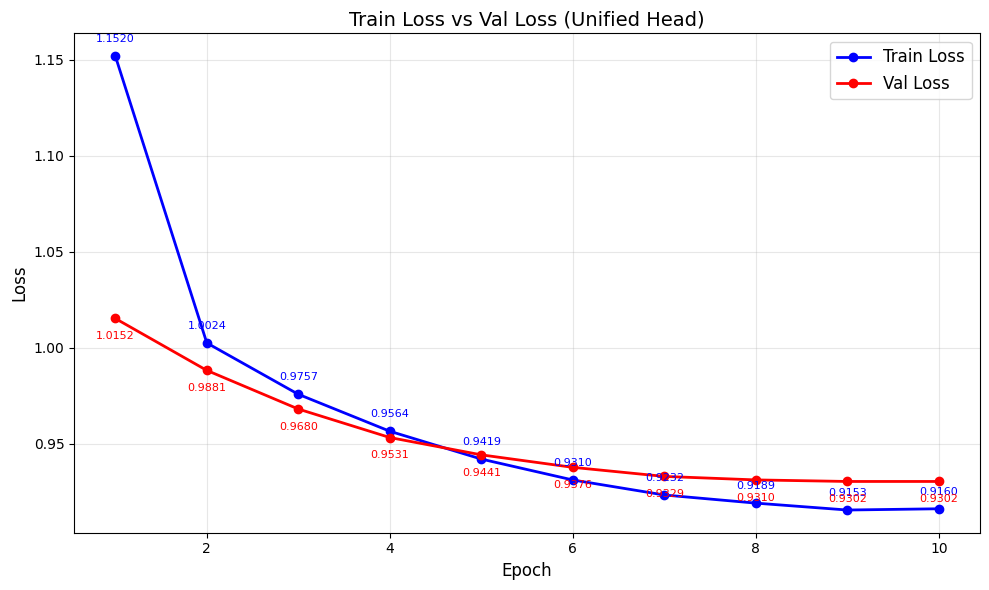

In [25]:
# ============================================
# PLOT TRAINING CURVES - Val Loss vs Train Loss
# ============================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

epochs_range = range(1, len(train_losses) + 1)

ax.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2)
ax.plot(epochs_range, val_losses, 'r-o', label='Val Loss', linewidth=2)

# Annotate values
for i, (t, v) in enumerate(zip(train_losses, val_losses)):
    ax.annotate(f"{t:.4f}", (i+1, t), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center', color='blue')
    ax.annotate(f"{v:.4f}", (i+1, v), textcoords="offset points", xytext=(0, -15), fontsize=8, ha='center', color='red')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Train Loss vs Val Loss (Unified Head)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Evaluation (Unified Head: 4-class per Aspect)



In [35]:
# ============================================
# EVALUATE ON TEST SET (Unified Head) - SIMPLE OUTPUT
# ============================================

from safetensors.torch import load_file
from sklearn.metrics import precision_score, recall_score, f1_score
import os

# Load best model from output3/
model_path = 'output3/best_model.safetensors'
info_path = 'output3/training_info.pt'

if os.path.exists(model_path):
    trainable_state = load_file(model_path)
    current_trainable_names = {
        name for name, param in sentiment_model.named_parameters() if param.requires_grad
    }
    missing_in_ckpt = sorted(current_trainable_names - set(trainable_state.keys()))
    unexpected_in_ckpt = sorted(set(trainable_state.keys()) - set(sentiment_model.state_dict().keys()))
    
    if missing_in_ckpt:
        print(f"[WARNING] Missing trainable keys in checkpoint: {missing_in_ckpt[:10]}")
    if unexpected_in_ckpt:
        print(f"[WARNING] Unexpected checkpoint keys: {unexpected_in_ckpt[:10]}")
    
    trainable_state = {k: v.to(device) for k, v in trainable_state.items()}
    sentiment_model.load_state_dict(trainable_state, strict=False)
    print(f"Loaded {len(trainable_state)} trainable tensors from {model_path}")
    
    if os.path.exists(info_path):
        try:
            info = torch.load(info_path, map_location='cpu', weights_only=True)
        except TypeError:
            info = torch.load(info_path, map_location='cpu')
        print(f"Loaded best model from epoch {info['epoch'] + 1}")
        print(f"  Val loss: {info['val_loss']}")
    else:
        print("Loaded best model from output3/")
else:
    print("[WARNING] No saved model found in output3/!")

# Evaluate on test set
test_loss, test_preds, test_labels = validate(
    sentiment_model, test_loader, criterion, device
)

print(f"\nTest Loss: {test_loss:.4f}")

if test_preds is None:
    print("[WARNING] Test evaluation produced no valid predictions.")
else:
    # Flatten [N, 6] -> [N*6] for macro metrics
    y_true = test_labels.numpy().ravel()
    y_pred = test_preds.numpy().ravel()

    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print("\n" + "=" * 70)
    print("UNIFIED HEAD EVALUATION RESULTS")
    print("=" * 70)
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall:    {macro_recall:.4f}")
    print(f"Macro F1:        {macro_f1:.4f}")

Loaded 200 trainable tensors from output3/best_model.safetensors
Loaded best model from epoch 9
  Val loss: 0.9302274193763733


Validating: 100% 125/125 [02:54<00:00,  1.40s/it]


Test Loss: 0.9696

UNIFIED HEAD EVALUATION RESULTS
Macro Precision: 0.4290
Macro Recall:    0.3106
Macro F1:        0.2650


In [29]:
# ============================================
# TEST 7: Save/Load Round-Trip
# Categories: Logic, Code Quality
# NOTE: This test only runs if output3/ has saved model files.
#       If training hasn't run yet, tests are skipped gracefully.
# ============================================
print("=" * 60)
print("TEST 7: Save/Load Round-Trip")
print("=" * 60)
_t7_passed = 0
_t7_total = 0
_t7_skipped = 0

_model_path = 'output3/best_model.safetensors'
_info_path = 'output3/training_info.pt'

if not os.path.exists(_model_path):
    print("  [SKIP] No saved model found in output3/ - run training first")
    _t7_skipped = 99
else:
    from safetensors.torch import load_file as _test_load_file

    # --- Logic: saved tensors match trainable param names ---
    _t7_total += 1
    _saved_state = _test_load_file(_model_path)
    _current_trainable_names = {
        name for name, param in sentiment_model.named_parameters() if param.requires_grad
    }
    _saved_names = set(_saved_state.keys())

    _missing_in_ckpt = _current_trainable_names - _saved_names
    _unexpected = _saved_names - set(sentiment_model.state_dict().keys())

    if _missing_in_ckpt:
        print(f"  [WARN] Missing trainable keys in checkpoint: {sorted(_missing_in_ckpt)[:5]}")
    if _unexpected:
        print(f"  [WARN] Unexpected keys in checkpoint: {sorted(_unexpected)[:5]}")

    assert len(_missing_in_ckpt) == 0, \
        f"{len(_missing_in_ckpt)} trainable params missing from saved model"
    assert len(_unexpected) == 0, \
        f"{len(_unexpected)} unexpected keys in saved model"
    print(f"  [PASS] Saved keys match trainable params: {len(_saved_state)} tensors")
    _t7_passed += 1

    # --- Logic: shapes match ---
    _t7_total += 1
    _shape_ok = True
    _model_state = sentiment_model.state_dict()
    for _k, _v in _saved_state.items():
        if _k in _model_state:
            if _v.shape != _model_state[_k].shape:
                print(f"  [FAIL] Shape mismatch: {_k}: saved={_v.shape} vs model={_model_state[_k].shape}")
                _shape_ok = False
    assert _shape_ok, "Shape mismatches found in saved state"
    print(f"  [PASS] All saved tensor shapes match model")
    _t7_passed += 1

    # --- Logic: load_state_dict works ---
    _t7_total += 1
    _saved_on_device = {k: v.to(device) for k, v in _saved_state.items()}
    _result = sentiment_model.load_state_dict(_saved_on_device, strict=False)
    # _result.missing_keys are non-trainable (expected), _result.unexpected_keys should be empty
    assert len(_result.unexpected_keys) == 0, \
        f"Unexpected keys when loading: {_result.unexpected_keys[:5]}"
    print(f"  [PASS] load_state_dict(strict=False): {len(_result.missing_keys)} non-trainable keys skipped (expected)")
    _t7_passed += 1

    # --- Logic: training_info.pt metadata ---
    if os.path.exists(_info_path):
        _t7_total += 1
        try:
            _info = torch.load(_info_path, map_location='cpu', weights_only=True)
        except TypeError:
            _info = torch.load(_info_path, map_location='cpu')

        assert _info['num_aspects'] == NUM_ASPECTS, \
            f"Saved num_aspects={_info['num_aspects']} != {NUM_ASPECTS}"
        assert _info['num_classes'] == NUM_CLASSES, \
            f"Saved num_classes={_info['num_classes']} != {NUM_CLASSES}"
        assert _info['aspect_labels'] == ASPECT_LABELS, \
            f"Saved aspect_labels mismatch"
        assert _info['class_labels'] == CLASS_LABELS, \
            f"Saved class_labels mismatch"

        # Check LoRA config consistency
        _saved_lora = _info.get('lora_config', {})
        assert _saved_lora.get('r') == 16, f"Saved lora_r={_saved_lora.get('r')}"
        assert _saved_lora.get('lora_alpha') == 16, f"Saved lora_alpha={_saved_lora.get('lora_alpha')}"
        assert set(_saved_lora.get('target_modules', [])) == {'q_proj', 'v_proj'}, \
            f"Saved target_modules={_saved_lora.get('target_modules')}"

        print(f"  [PASS] training_info.pt: metadata consistent (epoch={_info['epoch']}, "
              f"val_loss={_info['val_loss']:.4f})")
        _t7_passed += 1
    else:
        print("  [SKIP] training_info.pt not found")

    del _saved_state, _saved_on_device

if _t7_skipped == 99:
    print(f"\n{'='*60}")
    print("TEST 7 RESULT: ALL SKIPPED (no saved model)")
    print(f"{'='*60}")
else:
    print(f"\n{'='*60}")
    print(f"TEST 7 RESULT: {_t7_passed}/{_t7_total} PASSED")
    assert _t7_passed == _t7_total, f"TEST 7 FAILED: {_t7_total - _t7_passed} tests failed"
    print("ALL TESTS PASSED")
    print(f"{'='*60}")

TEST 7: Save/Load Round-Trip
  [PASS] Saved keys match trainable params: 200 tensors
  [PASS] All saved tensor shapes match model
  [PASS] load_state_dict(strict=False): 907 non-trainable keys skipped (expected)
  [PASS] training_info.pt: metadata consistent (epoch=8, val_loss=0.9302)

TEST 7 RESULT: 4/4 PASSED
ALL TESTS PASSED


---
## 8. Inference voi Trained Unified Head Pipeline



In [31]:
# ============================================
# INFERENCE FUNCTION - Unified Head
# ============================================

def predict_aspect_sentiment(
    image_path: str,
    comment: str,
    model: MultimodalSentimentModel = sentiment_model,
) -> dict:
    """
    Phan tich Aspect-Category Sentiment su dung trained Unified Head pipeline.
    
    Pipeline:
      Text  -> Tokenizer -> Embeddings ──┐
                                          ├──> [image | text] -> LLM -> Last-Token
      Image -> Swin V2 -> Projection ────┘    -> Unified Head -> [6, 4] -> argmax
    
    Args:
        image_path: Duong dan toi anh (single image for inference)
        comment: Text binh luan
        model: MultimodalSentimentModel da train
    
    Returns:
        Dict chua per-aspect predictions va probabilities
    """
    model.eval()
    
    # IMAGE PATH (single image)
    transform = build_transform(input_size=256)
    image = Image.open(image_path).convert("RGB")
    pixel_values = transform(image).unsqueeze(0).to(device, dtype=COMPUTE_DTYPE)
    
    # TEXT PATH
    text_inputs = tokenizer(
        [comment], padding=True, truncation=True, max_length=256, return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)
    
    # Forward
    with torch.no_grad():
        outputs = model(pixel_values, input_ids, attention_mask)
        logits = outputs["logits"].squeeze(0)  # [6, 4]
        probs = torch.softmax(logits, dim=-1).cpu()  # [6, 4]
        preds = logits.argmax(dim=-1).cpu()  # [6]
    
    # Build results
    detected_aspects = []
    aspect_sentiments = {}
    detailed = {}
    
    for a_idx in range(NUM_ASPECTS):
        aspect_name = ID2ASPECT[a_idx]
        pred_class = preds[a_idx].item()
        pred_label = ID2CLASS[pred_class]
        class_probs = probs[a_idx]  # [4]
        
        detailed[aspect_name] = {
            "predicted_class": pred_class,
            "predicted_label": pred_label,
            "probabilities": {
                ID2CLASS[c]: class_probs[c].item() for c in range(NUM_CLASSES)
            },
        }
        
        if pred_class > 0:  # Not "None"
            detected_aspects.append(aspect_name)
            aspect_sentiments[aspect_name] = pred_label
    
    return {
        "detected_aspects": detected_aspects,
        "aspect_sentiments": aspect_sentiments,
        "detailed": detailed,
    }


def predict_aspect_sentiment_batch(
    image_paths: list,
    comments: list,
    model: MultimodalSentimentModel = sentiment_model,
) -> list:
    """
    Predict Aspect-Category Sentiment cho nhieu samples cung luc.
    Uses single image per sample.
    """
    if len(image_paths) != len(comments):
        raise ValueError("image_paths and comments must have the same length")
    if len(image_paths) == 0:
        return []
    
    model.eval()
    transform = build_transform(input_size=256)
    
    # Load images
    pixel_list = []
    for img_path in image_paths:
        image = Image.open(img_path).convert("RGB")
        pixel_list.append(transform(image))
    pixel_values = torch.stack(pixel_list).to(device, dtype=COMPUTE_DTYPE)
    
    # Tokenize
    text_inputs = tokenizer(
        comments, padding=True, truncation=True, max_length=256, return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)
    
    # Forward (single image per sample)
    with torch.no_grad():
        outputs = model(pixel_values, input_ids, attention_mask)
        preds = outputs["logits"].argmax(dim=-1).cpu()  # [B, 6]
    
    results = []
    for i in range(len(image_paths)):
        detected_aspects = []
        aspect_sentiments = {}
        
        for a_idx in range(NUM_ASPECTS):
            pred_class = preds[i, a_idx].item()
            if pred_class > 0:
                aspect_name = ID2ASPECT[a_idx]
                detected_aspects.append(aspect_name)
                aspect_sentiments[aspect_name] = ID2CLASS[pred_class]
        
        results.append({
            "detected_aspects": detected_aspects,
            "aspect_sentiments": aspect_sentiments,
        })
    
    return results

In [32]:
# ============================================
# TEST 8: Inference Functions
# Categories: Runtime, Logic
# ============================================
print("=" * 60)
print("TEST 8: Inference Functions")
print("=" * 60)
_t8_passed = 0
_t8_total = 0

# Use a real sample from test dataset for testing
_t8_sample = test_dataset.samples[0]
_t8_img_path = _t8_sample["image_paths"][0]
_t8_comment = _t8_sample["comment"]

# --- Runtime: predict_aspect_sentiment returns correct structure ---
_t8_total += 1
_t8_result = predict_aspect_sentiment(_t8_img_path, _t8_comment)
_expected_keys = {"detected_aspects", "aspect_sentiments", "detailed"}
assert set(_t8_result.keys()) == _expected_keys, \
    f"Missing keys: {_expected_keys - set(_t8_result.keys())}"
print(f"  [PASS] predict_aspect_sentiment: correct keys {sorted(_t8_result.keys())}")
_t8_passed += 1

# --- Logic: detailed has all 6 aspects ---
_t8_total += 1
assert len(_t8_result["detailed"]) == NUM_ASPECTS, \
    f"detailed has {len(_t8_result['detailed'])} aspects != {NUM_ASPECTS}"
for _asp_name in ASPECT_LABELS:
    assert _asp_name in _t8_result["detailed"], f"Missing aspect: {_asp_name}"
print(f"  [PASS] All {NUM_ASPECTS} aspects present in detailed output")
_t8_passed += 1

# --- Logic: probabilities sum to ~1.0 per aspect ---
_t8_total += 1
_prob_ok = True
for _asp_name, _asp_info in _t8_result["detailed"].items():
    _probs = _asp_info["probabilities"]
    _prob_sum = sum(_probs.values())
    if abs(_prob_sum - 1.0) > 0.01:
        print(f"  [FAIL] {_asp_name}: prob sum = {_prob_sum:.4f} (expected ~1.0)")
        _prob_ok = False
    # Check each probability is in [0, 1]
    for _cls, _p in _probs.items():
        if _p < 0 or _p > 1:
            print(f"  [FAIL] {_asp_name}/{_cls}: prob={_p} out of [0,1]")
            _prob_ok = False
assert _prob_ok, "Probability issues found"
print(f"  [PASS] Probabilities sum to ~1.0 per aspect, all in [0,1]")
_t8_passed += 1

# --- Logic: predicted_class matches label mapping ---
_t8_total += 1
_class_ok = True
for _asp_name, _asp_info in _t8_result["detailed"].items():
    _pred_class = _asp_info["predicted_class"]
    _pred_label = _asp_info["predicted_label"]
    assert 0 <= _pred_class < NUM_CLASSES, f"{_asp_name}: class={_pred_class} out of range"
    assert _pred_label == ID2CLASS[_pred_class], \
        f"{_asp_name}: label='{_pred_label}' != ID2CLASS[{_pred_class}]='{ID2CLASS[_pred_class]}'"
if _class_ok:
    print(f"  [PASS] predicted_class <-> predicted_label mapping correct")
    _t8_passed += 1

# --- Logic: detected_aspects only includes non-None predictions ---
_t8_total += 1
for _asp_name in _t8_result["detected_aspects"]:
    assert _t8_result["detailed"][_asp_name]["predicted_class"] > 0, \
        f"'{_asp_name}' in detected_aspects but class=0 (None)"
# Also check no aspect with class > 0 is missing from detected_aspects
for _asp_name, _asp_info in _t8_result["detailed"].items():
    if _asp_info["predicted_class"] > 0:
        assert _asp_name in _t8_result["detected_aspects"], \
            f"'{_asp_name}' has class {_asp_info['predicted_class']} but not in detected_aspects"
print(f"  [PASS] detected_aspects consistent with predictions: {_t8_result['detected_aspects']}")
_t8_passed += 1

# --- Runtime: predict_aspect_sentiment_batch ---
_t8_total += 1
_t8_samples = test_dataset.samples[:3]
_t8_imgs = [s["image_paths"][0] for s in _t8_samples]
_t8_comments = [s["comment"] for s in _t8_samples]
_t8_batch_results = predict_aspect_sentiment_batch(_t8_imgs, _t8_comments)
assert len(_t8_batch_results) == 3, f"Batch result length: {len(_t8_batch_results)} != 3"
for _i, _r in enumerate(_t8_batch_results):
    assert "detected_aspects" in _r, f"Sample {_i}: missing 'detected_aspects'"
    assert "aspect_sentiments" in _r, f"Sample {_i}: missing 'aspect_sentiments'"
print(f"  [PASS] predict_aspect_sentiment_batch: {len(_t8_batch_results)} results, correct structure")
_t8_passed += 1

# --- Runtime: batch with mismatched lengths should raise error ---
_t8_total += 1
try:
    predict_aspect_sentiment_batch(["path1", "path2"], ["only_one_comment"])
    print(f"  [FAIL] Should have raised ValueError for mismatched lengths")
except ValueError:
    print(f"  [PASS] ValueError raised for mismatched image_paths/comments lengths")
    _t8_passed += 1

# Cleanup
del _t8_result, _t8_batch_results

print(f"\n{'='*60}")
print(f"TEST 8 RESULT: {_t8_passed}/{_t8_total} PASSED")
assert _t8_passed == _t8_total, f"TEST 8 FAILED: {_t8_total - _t8_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

TEST 8: Inference Functions
  [PASS] predict_aspect_sentiment: correct keys ['aspect_sentiments', 'detailed', 'detected_aspects']
  [PASS] All 6 aspects present in detailed output
  [PASS] Probabilities sum to ~1.0 per aspect, all in [0,1]
  [PASS] predicted_class <-> predicted_label mapping correct
  [PASS] detected_aspects consistent with predictions: ['Facilities', 'Public_area', 'Location', 'Food', 'Room', 'Service']
  [PASS] predict_aspect_sentiment_batch: 3 results, correct structure
  [PASS] ValueError raised for mismatched image_paths/comments lengths

TEST 8 RESULT: 7/7 PASSED
ALL TESTS PASSED


Comment: trải nghiệm dịch vụ chất lượng cao, tuyệt vời, hồ bơi rộng sạch, thích hợp để nghỉ dưỡng, khu resort rất gần vinwonder và grandworld
True labels: ['Location#Positive', 'Facilities#Positive', 'Service#Positive', 'Public_area#Neutral']
Available images: 1



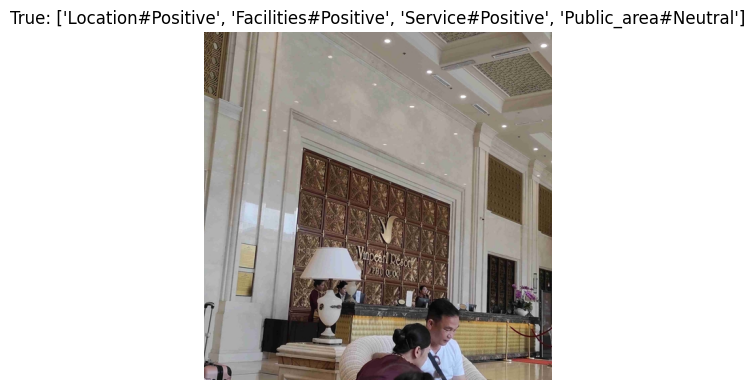

PREDICTION (Unified Head Pipeline):

  Detected Aspects: ['Facilities', 'Public_area', 'Location', 'Food', 'Room', 'Service']

  Aspect-Sentiments:
    Facilities: Positive
    Public_area: Positive
    Location: Positive
    Food: Positive
    Room: Positive
    Service: Positive

  Detailed Probabilities:
  >>> Facilities      -> [None: 0.293, Negative: 0.041, Neutral: 0.103, Positive: 0.563] -> Positive
  >>> Public_area     -> [None: 0.028, Negative: 0.011, Neutral: 0.111, Positive: 0.849] -> Positive
  >>> Location        -> [None: 0.328, Negative: 0.028, Neutral: 0.033, Positive: 0.610] -> Positive
  >>> Food            -> [None: 0.153, Negative: 0.045, Neutral: 0.052, Positive: 0.750] -> Positive
  >>> Room            -> [None: 0.166, Negative: 0.042, Neutral: 0.104, Positive: 0.688] -> Positive
  >>> Service         -> [None: 0.348, Negative: 0.053, Neutral: 0.034, Positive: 0.566] -> Positive


In [33]:
# ============================================
# DEMO INFERENCE - Unified Head Pipeline
# ============================================

import matplotlib.pyplot as plt

# Lay 1 sample tu test set
demo_sample = test_dataset.samples[0]
demo_image_path = demo_sample["image_paths"][0]  # First image for demo
demo_comment = demo_sample["comment"]
demo_true_labels = demo_sample["raw_labels"]

print(f"Comment: {demo_comment}")
print(f"True labels: {demo_true_labels}")
print(f"Available images: {len(demo_sample['image_paths'])}")
print()

# Hien thi anh
img = Image.open(demo_image_path)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"True: {demo_true_labels}")
plt.tight_layout()
plt.show()

# Predict su dung trained Unified Head pipeline
result = predict_aspect_sentiment(demo_image_path, demo_comment)

print("=" * 60)
print("PREDICTION (Unified Head Pipeline):")
print("=" * 60)
print(f"\n  Detected Aspects: {result['detected_aspects']}")
print(f"\n  Aspect-Sentiments:")
for aspect, sentiment in result['aspect_sentiments'].items():
    print(f"    {aspect}: {sentiment}")

print(f"\n  Detailed Probabilities:")
for aspect, info in result['detailed'].items():
    marker = ">>>" if info["predicted_class"] > 0 else "   "
    probs_str = ", ".join([f"{c}: {p:.3f}" for c, p in info['probabilities'].items()])
    print(f"  {marker} {aspect:<15} -> [{probs_str}] -> {info['predicted_label']}")
print("=" * 60)

In [34]:
# ============================================
# TEST 9: Cross-Module Integration Tests
# Categories: End-to-end, Config consistency, Dtype chain
# ============================================
print("=" * 60)
print("TEST 9: Cross-Module Integration Tests")
print("=" * 60)
_t9_passed = 0
_t9_total = 0

# --- End-to-end: raw batch → model → logits → loss → backward → grads finite ---
_t9_total += 1
sentiment_model.train()
optimizer.zero_grad(set_to_none=True)

_e2e_batch = next(iter(train_loader))
_e2e_pv = _e2e_batch['pixel_values'].to(device, dtype=COMPUTE_DTYPE)
_e2e_ic = _e2e_batch['image_counts'].to(device)
_e2e_ids = _e2e_batch['input_ids'].to(device)
_e2e_am = _e2e_batch['attention_mask'].to(device)
_e2e_labels = _e2e_batch['labels'].to(device)

_e2e_out = sentiment_model(_e2e_pv, _e2e_ids, _e2e_am, _e2e_ic)
_e2e_logits = _e2e_out['logits']
_e2e_loss = compute_loss(_e2e_logits, _e2e_labels, criterion)

assert torch.isfinite(_e2e_loss), f"E2E loss is NaN/Inf: {_e2e_loss.item()}"
_e2e_loss.backward()

_e2e_grad_ok = True
_e2e_grad_count = 0
_e2e_nan_params = []
for _n, _p in sentiment_model.named_parameters():
    if _p.requires_grad and _p.grad is not None:
        _e2e_grad_count += 1
        if not torch.isfinite(_p.grad).all():
            _e2e_nan_params.append(_n)
            _e2e_grad_ok = False

if _e2e_grad_ok:
    print(f"  [PASS] End-to-end: forward→loss→backward OK, "
          f"loss={_e2e_loss.item():.4f}, {_e2e_grad_count} param grads all finite")
    _t9_passed += 1
else:
    print(f"  [FAIL] End-to-end: {len(_e2e_nan_params)} params have NaN/Inf grads: {_e2e_nan_params[:5]}")

optimizer.zero_grad(set_to_none=True)

# --- Config consistency: NUM_ASPECTS/NUM_CLASSES same everywhere ---
_t9_total += 1
assert sentiment_model.num_aspects == NUM_ASPECTS == len(ASPECT_LABELS) == len(ASPECT2ID), \
    "NUM_ASPECTS inconsistent across global/model/labels"
assert sentiment_model.num_classes == NUM_CLASSES == len(CLASS_LABELS) == len(CLASS2ID), \
    "NUM_CLASSES inconsistent across global/model/labels"
assert sentiment_model.unified_head.out_features == NUM_ASPECTS * NUM_CLASSES, \
    "unified_head output doesn't match NUM_ASPECTS * NUM_CLASSES"
assert criterion.weight.shape[0] == NUM_CLASSES, \
    "criterion weight size doesn't match NUM_CLASSES"
print(f"  [PASS] Config consistency: NUM_ASPECTS={NUM_ASPECTS}, NUM_CLASSES={NUM_CLASSES} everywhere")
_t9_passed += 1

# --- Dtype chain: vision(bf16) → projector(fp32) → cast(bf16) → LLM(bf16) → cast(fp32) → head(fp32) ---
_t9_total += 1
_dtype_vision = vision_encoder.torch_dtype
_dtype_projector = next(projector.parameters()).dtype
_dtype_llm = sentiment_model.llm_dtype
_dtype_head = next(sentiment_model.unified_head.parameters()).dtype
_dtype_logits = _e2e_logits.dtype

assert _dtype_vision == COMPUTE_DTYPE, f"Vision dtype={_dtype_vision} != {COMPUTE_DTYPE}"
assert _dtype_projector == torch.float32, f"Projector dtype={_dtype_projector} != float32"
assert _dtype_llm == COMPUTE_DTYPE, f"LLM dtype={_dtype_llm} != {COMPUTE_DTYPE}"
assert _dtype_head == torch.float32, f"Head dtype={_dtype_head} != float32"
assert _dtype_logits == torch.float32, f"Logits dtype={_dtype_logits} != float32"

print(f"  [PASS] Dtype chain: vision({_dtype_vision}) → projector({_dtype_projector}) "
      f"→ LLM({_dtype_llm}) → head({_dtype_head}) → logits({_dtype_logits})")
_t9_passed += 1

# --- Architecture: projector input matches vision output, projector output matches LLM ---
_t9_total += 1
assert projector.projector[1].in_features == vision_encoder.hidden_size, \
    f"Projector in={projector.projector[1].in_features} != vision={vision_encoder.hidden_size}"
assert projector.projector[-1].out_features == sentiment_model.llm_hidden_size, \
    f"Projector out={projector.projector[-1].out_features} != LLM={sentiment_model.llm_hidden_size}"
assert sentiment_model.unified_head.in_features == sentiment_model.llm_hidden_size, \
    f"Head in={sentiment_model.unified_head.in_features} != LLM={sentiment_model.llm_hidden_size}"
print(f"  [PASS] Dimension chain: vision({vision_encoder.hidden_size}) → "
      f"projector → ({sentiment_model.llm_hidden_size}) → LLM → head → ({NUM_ASPECTS * NUM_CLASSES})")
_t9_passed += 1

# --- Code Quality: tokenizer config matches model usage ---
_t9_total += 1
assert tokenizer.padding_side == 'right', f"padding_side='{tokenizer.padding_side}'"
assert tokenizer.pad_token_id is not None, "pad_token_id is None"
# Verify text_embeddings matches tokenizer's model embeddings
_emb_vocab = sentiment_model.text_embeddings.num_embeddings
_tok_vocab = len(tokenizer)
# Allow tokenizer to be slightly larger (due to added tokens) but embeddings must cover it
assert _emb_vocab >= _tok_vocab or abs(_emb_vocab - _tok_vocab) < 10, \
    f"Embedding vocab={_emb_vocab} vs tokenizer vocab={_tok_vocab} (large mismatch)"
print(f"  [PASS] Tokenizer config: padding_side='right', pad_token_id={tokenizer.pad_token_id}, "
      f"vocab={_tok_vocab}")
_t9_passed += 1

# --- Memory: no leftover gradients after cleanup ---
_t9_total += 1
optimizer.zero_grad(set_to_none=True)
_any_residual_grad = False
for _n, _p in sentiment_model.named_parameters():
    if _p.grad is not None:
        _any_residual_grad = True
        break
assert not _any_residual_grad, "Residual gradients found after zero_grad(set_to_none=True)"
print(f"  [PASS] No residual gradients after optimizer.zero_grad(set_to_none=True)")
_t9_passed += 1

# Cleanup
del _e2e_batch, _e2e_pv, _e2e_ic, _e2e_ids, _e2e_am, _e2e_labels, _e2e_out, _e2e_logits, _e2e_loss
torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"TEST 9 RESULT: {_t9_passed}/{_t9_total} PASSED")
assert _t9_passed == _t9_total, f"TEST 9 FAILED: {_t9_total - _t9_passed} tests failed"
print("ALL TESTS PASSED")
print(f"{'='*60}")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "#" * 60)
print("# ALL 9 TEST SUITES COMPLETED SUCCESSFULLY")
print("#" * 60)
print("# Test 1: VisionEncoder + MLPProjector  - Runtime, Architecture, Memory")
print("# Test 2: LLM + Tokenizer               - Runtime, Architecture, Dtype")
print("# Test 3: Dataset + DataLoader + Collate - Runtime, Logic, Padding")
print("# Test 4: MultimodalSentimentModel       - Runtime, Architecture, Logic, Dtype")
print("# Test 5: Training Config                - Logic, Code Quality")
print("# Test 6: Training Loop Functions         - Logic, Runtime")
print("# Test 7: Save/Load Round-Trip           - Logic, Code Quality")
print("# Test 8: Inference Functions             - Runtime, Logic")
print("# Test 9: Cross-Module Integration       - E2E, Config, Dtype Chain")
print("#" * 60)

TEST 9: Cross-Module Integration Tests
  [PASS] End-to-end: forward→loss→backward OK, loss=0.9934, 200 param grads all finite
  [PASS] Config consistency: NUM_ASPECTS=6, NUM_CLASSES=4 everywhere
  [PASS] Dtype chain: vision(torch.bfloat16) → projector(torch.float32) → LLM(torch.bfloat16) → head(torch.float32) → logits(torch.float32)
  [PASS] Dimension chain: vision(1024) → projector → (4096) → LLM → head → (24)
  [PASS] Tokenizer config: padding_side='right', pad_token_id=2, vocab=128133
  [PASS] No residual gradients after optimizer.zero_grad(set_to_none=True)

TEST 9 RESULT: 6/6 PASSED
ALL TESTS PASSED

############################################################
# ALL 9 TEST SUITES COMPLETED SUCCESSFULLY
############################################################
# Test 1: VisionEncoder + MLPProjector  - Runtime, Architecture, Memory
# Test 2: LLM + Tokenizer               - Runtime, Architecture, Dtype
# Test 3: Dataset + DataLoader + Collate - Runtime, Logic, Padding
# Test 4: Mu